# Integrative Challenge - Part 1 : Environment (RoboArena 4.0)

The Integrative Challenge is split into three activities. This notebook is only for the first one: building the environment (production line, racks, truck dock, charging stations, parking slot, corridors, pallet positions) on a discrete grid. No AGV agents, no decisions, no communication yet, that's for the next activity.

I used AgentPy, so the grid and the static elements are built as an AgentPy Model, but none of the agents placed here actually do anything (no `step()`), they just hold a position and a type.


In [1]:
!pip install agentpy

# Step 1 - Imports

In [2]:
import agentpy as ap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

# Step 2 - Layout parameters

Everything about the environment is in one dictionary, `CONFIG`, so I can move something around without touching the rest of the notebook.

1 cell = 0.3 m, roughly the AGV footprint given in the project brief (30x20cm). The real RoboArena 4.0 platform is about 4.5 x 3.5 m, so with this scale I get a 15 x 12 grid (4.5 x 3.6 m, close enough to 3.5).

The production line is the column at x=0 and the truck dock is the column at x=14. Both only have 4 cells you can actually reach: for the production line these are the 4 outputs, for the dock these are 4 doors. I didn't split the dock into separate inbound/outbound zones, a door can be used for either, it depends on the mission and not on the door itself.

The two charging stations are at the two ends of the bottom row and the parking slot (where an AGV waits if both CS are busy) is centered between them.

Corridors are 2 cells wide almost everywhere, except the gap between the two middle racks, which I left at 1 cell on purpose, so I can test later what happens when two AGVs want to go through the same narrow spot at once.


In [3]:
CONFIG = {
    "cell_size_m": 0.3,     # ~ AGV footprint
    "grid_width": 15,       # 15 * 0.3 = 4.5 m
    "grid_height": 12,      # 12 * 0.3 = 3.6 m (real platform is ~3.5 m)

    "production_line": {
        "id": "production_line",
        "x": 0, "y": 0, "w": 1, "h": 12,
        "output_rows": [1, 4, 7, 10],
    },
    "truck_dock": {
        "id": "truck_dock",
        "x": 14, "y": 0, "w": 1, "h": 12,
        "door_rows": [1, 4, 7, 10],
    },

    "racks": [
        {"id": "rack_top",       "x": 5, "y": 10, "w": 5, "h": 2, "pallet_face": "bottom"},
        {"id": "rack_mid_upper", "x": 3, "y": 6,  "w": 4, "h": 2, "pallet_face": "top"},   # top, not bottom, so it doesn't sit right on the narrow gap
        {"id": "rack_mid_lower", "x": 3, "y": 3,  "w": 4, "h": 2, "pallet_face": "bottom"},
        {"id": "rack_vertical",  "x": 9, "y": 3,  "w": 2, "h": 5, "pallet_face": "left"},
    ],
    "max_pallet_slots_per_rack": 4,

    "charging_stations": [
        {"id": "cs_1", "x": 1,  "y": 0, "w": 1, "h": 1},
        {"id": "cs_2", "x": 13, "y": 0, "w": 1, "h": 1},
    ],
    "parking_slot": {"id": "parking_1", "x": 6, "y": 0, "w": 3, "h": 1},
}

# codes for the zone_map array, only used for plotting/debugging
ZONE_CODES = {
    "corridor": 0,
    "rack": 1,
    "charging_station": 2,
    "parking_slot": 3,
    "production_line_wall": 4,
    "production_line_output": 5,
    "truck_dock_wall": 6,
    "truck_dock_door": 7,
    "pallet_position": 8,
}

Each rack can hold up to 4 pallets at the same time. Instead of typing every coordinate by hand, I wrote a small function that spreads the slots along the accessible side of the rack (the side facing a corridor, not a wall or another rack), capped at 4 slots or at the length of that side, whichever is smaller.

In [4]:
def generate_pallet_slots(rack, max_slots):
    x0, y0, w, h = rack["x"], rack["y"], rack["w"], rack["h"]
    face = rack["pallet_face"]

    length = w if face in ("top", "bottom") else h
    nb_slots = min(max_slots, length)
    step = length / nb_slots
    offsets = [int(i * step) for i in range(nb_slots)]

    slots = []
    for off in offsets:
        if face == "bottom":
            slots.append((x0 + off, y0 - 1))
        elif face == "top":
            slots.append((x0 + off, y0 + h))
        elif face == "left":
            slots.append((x0 - 1, y0 + off))
        elif face == "right":
            slots.append((x0 + w, y0 + off))

    return slots


CONFIG["pallet_positions"] = []
for rack in CONFIG["racks"]:
    slots = generate_pallet_slots(rack, CONFIG["max_pallet_slots_per_rack"])
    for i, (x, y) in enumerate(slots):
        CONFIG["pallet_positions"].append({
            "id": rack["id"] + "_pallet_" + str(i + 1),
            "rack_id": rack["id"],
            "x": x, "y": y,
        })

print("total pallet slots:", len(CONFIG["pallet_positions"]))
for rack in CONFIG["racks"]:
    n = len([p for p in CONFIG["pallet_positions"] if p["rack_id"] == rack["id"]])
    print(" -", rack["id"], ":", n, "slots")

total pallet slots: 16
 - rack_top : 4 slots
 - rack_mid_upper : 4 slots
 - rack_mid_lower : 4 slots
 - rack_vertical : 4 slots


# Step 3 - Environment model (AgentPy)

The environment is an AgentPy `Model`. Every cell that belongs to a zone (rack, dock, charging station, ...) gets its own `StaticZoneAgent`, but that agent has no behavior, it only stores a type, an id and whether it's walkable or not.

Next to that I keep a numpy array `walkable` (True/False per cell) and a list `zones` with the x,y,w,h of every element. Those two are what I'll actually reuse in the next activity for the AGV pathfinding and the pickup/drop-off points.


In [5]:
class StaticZoneAgent(ap.Agent):
    # just holds the type of one grid cell, no behavior for this activity

    def setup(self):
        self.zone_type = None
        self.zone_id = None
        self.walkable = False


class LogisticsEnvironment(ap.Model):

    def setup(self):
        p = self.p
        self.width = p["grid_width"]
        self.height = p["grid_height"]

        self.grid = ap.Grid(self, (self.height, self.width), track_empty=True)

        self.zone_map = np.zeros((self.height, self.width), dtype=int)
        self.walkable = np.ones((self.height, self.width), dtype=bool)
        self.zones = []

        self.place_production_line(p["production_line"])
        self.place_truck_dock(p["truck_dock"])

        for rack in p["racks"]:
            self.place_block(rack, "rack", walkable=False)

        for cs in p["charging_stations"]:
            self.place_block(cs, "charging_station", walkable=True)

        self.place_block(p["parking_slot"], "parking_slot", walkable=True)
        self.place_pallet_positions(p["pallet_positions"])

    def add_cell(self, x, y, zone_type, zone_id, walkable):
        agent = StaticZoneAgent(self)
        agent.zone_type = zone_type
        agent.zone_id = zone_id
        agent.walkable = walkable
        self.grid.add_agents([agent], positions=[(y, x)])   # agentpy grid positions are (row, col)
        self.zone_map[y, x] = ZONE_CODES[zone_type]
        self.walkable[y, x] = walkable

    def place_block(self, spec, zone_type, walkable):
        x0, y0, w, h = spec["x"], spec["y"], spec["w"], spec["h"]
        for y in range(y0, y0 + h):
            for x in range(x0, x0 + w):
                self.add_cell(x, y, zone_type, spec["id"], walkable)
        self.zones.append({"id": spec["id"], "type": zone_type, "x": x0, "y": y0, "w": w, "h": h})

    def place_production_line(self, spec):
        x0, y0, w, h = spec["x"], spec["y"], spec["w"], spec["h"]
        outputs = spec["output_rows"]
        for y in range(y0, y0 + h):
            if y in outputs:
                self.add_cell(x0, y, "production_line_output", spec["id"], walkable=True)
            else:
                self.add_cell(x0, y, "production_line_wall", spec["id"], walkable=False)
        self.zones.append({"id": spec["id"], "type": "production_line", "x": x0, "y": y0, "w": w, "h": h})

    def place_truck_dock(self, spec):
        x0, y0, w, h = spec["x"], spec["y"], spec["w"], spec["h"]
        doors = spec["door_rows"]
        for y in range(y0, y0 + h):
            if y in doors:
                self.add_cell(x0, y, "truck_dock_door", spec["id"], walkable=True)
            else:
                self.add_cell(x0, y, "truck_dock_wall", spec["id"], walkable=False)
        self.zones.append({"id": spec["id"], "type": "truck_dock", "x": x0, "y": y0, "w": w, "h": h})

    def place_pallet_positions(self, specs):
        for spec in specs:
            self.add_cell(spec["x"], spec["y"], "pallet_position", spec["id"], walkable=True)
            self.zones.append({"id": spec["id"], "type": "pallet_position",
                                "x": spec["x"], "y": spec["y"], "w": 1, "h": 1,
                                "rack_id": spec["rack_id"]})

In [6]:
env = LogisticsEnvironment(CONFIG)
env.setup()

print("grid size (rows, cols):", env.zone_map.shape)
print("number of zone agents:", len(env.grid.agents))
print("number of zones:", len(env.zones))
print("walkable cells:", env.walkable.sum(), "/", env.walkable.size)

grid size (rows, cols): (12, 15)
number of zone agents: 81
number of zones: 25
walkable cells: 128 / 180


A couple of quick checks on the layout, just printed out instead of a real test suite: that racks/CS/parking don't overlap, that the narrow gap between the two middle racks really is 1 cell wide, and that every pallet slot lands on a walkable cell.

In [7]:
# racks / CS / parking should never overlap each other
occupied = np.zeros_like(env.zone_map)
for z in CONFIG["racks"] + CONFIG["charging_stations"] + [CONFIG["parking_slot"]]:
    occupied[z["y"]:z["y"]+z["h"], z["x"]:z["x"]+z["w"]] += 1
print("max overlap count (should be 1):", occupied.max())

# column x=4 crosses both middle racks and the gap between them
print("walkable column at x=4, from y=0 to y=11:")
print(env.walkable[:, 4].astype(int))

# every pallet slot should be walkable and inside the grid
bad = 0
for p in CONFIG["pallet_positions"]:
    inside = 0 <= p["x"] < env.width and 0 <= p["y"] < env.height
    if not inside or not env.walkable[p["y"], p["x"]]:
        bad += 1
        print("problem with slot:", p)
print(len(CONFIG["pallet_positions"]) - bad, "/", len(CONFIG["pallet_positions"]), "pallet slots OK")

max overlap count (should be 1): 1
walkable column at x=4, from y=0 to y=11:
[1 1 1 0 0 1 0 0 1 1 1 1]
16 / 16 pallet slots OK


# Step 4 - Visualization

To check the layout without reading the code, I draw the grid with matplotlib: a colored rectangle per zone, arrows on the production line outputs and dock doors, and small diamonds for the pallet slots.


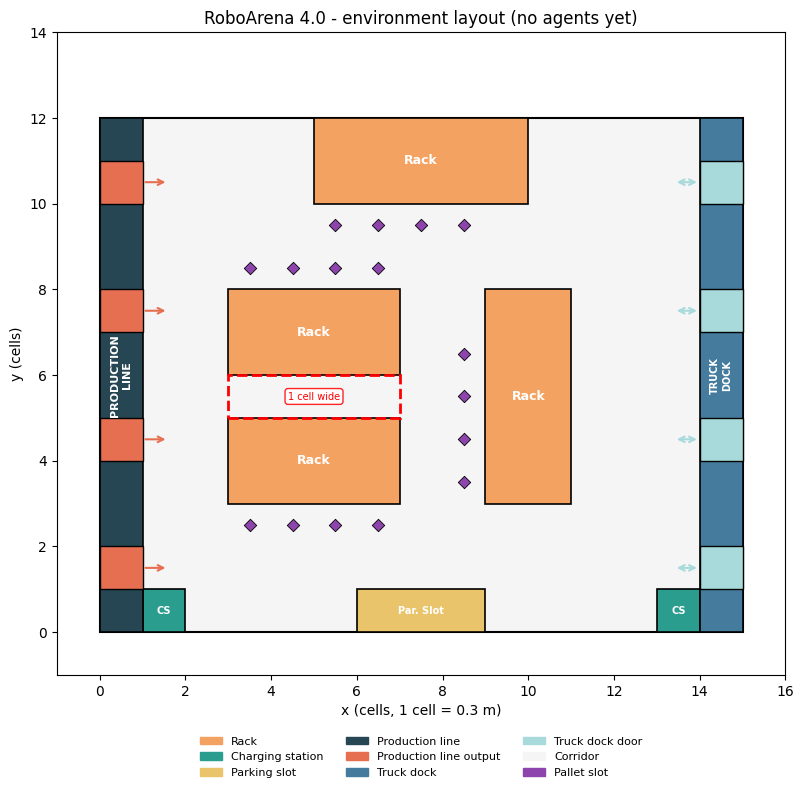

In [8]:
COLORS = {
    "corridor": "#f5f5f5",
    "rack": "#f4a261",
    "charging_station": "#2a9d8f",
    "parking_slot": "#e9c46a",
    "production_line": "#264653",
    "truck_dock": "#457b9d",
    "pallet_position": "#8e44ad",
}


def draw_block(ax, x, y, w, h, color, label, fontsize=9):
    ax.add_patch(mpatches.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", linewidth=1.2, zorder=2))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", color="white", fontsize=fontsize, weight="bold", zorder=3)


def plot_environment(config, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 8))
    W, H = config["grid_width"], config["grid_height"]

    ax.add_patch(mpatches.Rectangle((0, 0), W, H, facecolor=COLORS["corridor"], edgecolor="black", linewidth=1.5))

    for gx in range(W + 1):
        ax.plot([gx, gx], [0, H], color="#dddddd", linewidth=0.5, zorder=0)
    for gy in range(H + 1):
        ax.plot([0, W], [gy, gy], color="#dddddd", linewidth=0.5, zorder=0)

    for r in config["racks"]:
        draw_block(ax, r["x"], r["y"], r["w"], r["h"], COLORS["rack"], "Rack")

    for cs in config["charging_stations"]:
        draw_block(ax, cs["x"], cs["y"], cs["w"], cs["h"], COLORS["charging_station"], "CS", fontsize=7)

    p = config["parking_slot"]
    draw_block(ax, p["x"], p["y"], p["w"], p["h"], COLORS["parking_slot"], "Par. Slot", fontsize=7)

    pl = config["production_line"]
    draw_block(ax, pl["x"], pl["y"], pl["w"], pl["h"], COLORS["production_line"], "")
    for oy in pl["output_rows"]:
        ax.add_patch(mpatches.Rectangle((pl["x"], oy), pl["w"], 1, facecolor="#e76f51", edgecolor="black", zorder=3))
        ax.annotate("", xy=(pl["x"] + pl["w"] + 0.6, oy + 0.5), xytext=(pl["x"] + pl["w"], oy + 0.5),
                    arrowprops=dict(arrowstyle="->", color="#e76f51", lw=1.5), zorder=4)
    ax.text(pl["x"] + pl["w"] / 2, pl["y"] + pl["h"] / 2, "PRODUCTION\nLINE", rotation=90,
            ha="center", va="center", color="white", fontsize=8, weight="bold", zorder=3)

    td = config["truck_dock"]
    draw_block(ax, td["x"], td["y"], td["w"], td["h"], COLORS["truck_dock"], "")
    for dy in td["door_rows"]:
        ax.add_patch(mpatches.Rectangle((td["x"], dy), td["w"], 1, facecolor="#a8dadc", edgecolor="black", zorder=3))
        ax.annotate("", xy=(td["x"] - 0.6, dy + 0.5), xytext=(td["x"], dy + 0.5),
                    arrowprops=dict(arrowstyle="<->", color="#a8dadc", lw=1.5), zorder=4)
    ax.text(td["x"] + td["w"] / 2, td["y"] + td["h"] / 2, "TRUCK\nDOCK", rotation=90,
            ha="center", va="center", color="white", fontsize=7, weight="bold", zorder=3)

    for pp in config["pallet_positions"]:
        ax.scatter(pp["x"] + 0.5, pp["y"] + 0.5, marker="D", s=40,
                   color=COLORS["pallet_position"], edgecolor="black", linewidth=0.6, zorder=5)

    # the narrow passage between the two middle racks, marked so it's easy to spot
    ax.add_patch(mpatches.Rectangle((3, 5), 4, 1, facecolor="none", edgecolor="red", linewidth=2, linestyle="--", zorder=6))
    ax.text(5, 5.5, "1 cell wide", ha="center", va="center", fontsize=7, color="red", zorder=6,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.85))

    ax.set_xlim(-1, W + 1)
    ax.set_ylim(-1, H + 2)
    ax.set_aspect("equal")
    ax.set_xlabel(f"x (cells, 1 cell = {config['cell_size_m']} m)")
    ax.set_ylabel("y (cells)")
    ax.set_title("RoboArena 4.0 - environment layout (no agents yet)")

    legend_items = [
        mpatches.Patch(color=COLORS["rack"], label="Rack"),
        mpatches.Patch(color=COLORS["charging_station"], label="Charging station"),
        mpatches.Patch(color=COLORS["parking_slot"], label="Parking slot"),
        mpatches.Patch(color=COLORS["production_line"], label="Production line"),
        mpatches.Patch(color="#e76f51", label="Production line output"),
        mpatches.Patch(color=COLORS["truck_dock"], label="Truck dock"),
        mpatches.Patch(color="#a8dadc", label="Truck dock door"),
        mpatches.Patch(color=COLORS["corridor"], label="Corridor"),
        mpatches.Patch(color=COLORS["pallet_position"], label="Pallet slot"),
    ]
    ax.legend(handles=legend_items, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8, frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_environment(CONFIG, save_path="environment_preview.png")

# Step 5 - Saving the layout

I save the grid size, the list of zones and the walkable mask to a json file. I don't need this for the current activity, but it should save time later for the Unity part since the coordinates will already be there.


In [9]:
export = {
    "grid": {
        "width_cells": CONFIG["grid_width"],
        "height_cells": CONFIG["grid_height"],
        "cell_size_m": CONFIG["cell_size_m"],
    },
    "zones": env.zones,
    "walkable_mask": env.walkable.astype(int).tolist(),
}

with open("layout_export.json", "w") as f:
    json.dump(export, f, indent=2)

print("saved layout_export.json")
print("grid:", CONFIG["grid_width"], "x", CONFIG["grid_height"], "cells")
print("real size:", round(CONFIG["grid_width"] * CONFIG["cell_size_m"], 2), "x",
      round(CONFIG["grid_height"] * CONFIG["cell_size_m"], 2), "m")

saved layout_export.json
grid: 15 x 12 cells
real size: 4.5 x 3.6 m


# Short analysis

**1. How did I represent the environment?**
As a discrete grid, 15 by 12 cells, 0.3 m per cell. It's built as an AgentPy Model, and every cell that belongs to a zone has its own agent (just a type, no behavior). The `walkable` array and the `zones` list are what I actually use for the plot and the export.

**2. What elements did I include?**
Production line (4 outputs), truck dock (4 doors, shared between inbound and outbound), 4 racks, 2 charging stations, 1 parking slot, 16 pallet slots (up to 4 per rack), corridors, and the obstacle cells (the racks themselves, plus the wall parts of the production line and the dock).

**3. What did I change compared to the example seen in class?**
Mostly the scale, I matched it to the real AGV footprint and to the real dimensions of RoboArena 4.0 instead of picking arbitrary numbers. I also merged the production line into one object with 4 outputs instead of 4 separate ones, did the same for the dock instead of two separate inbound/outbound zones, and added the pallet slots and the narrow corridor. I also added a parking slot where AGV can parking waiting for a free charging station.

**4. Why this layout?**
It follows the layout I sketched for RoboArena 4.0: a rack at the top, two stacked racks on the left, one long rack on the right, charging stations and parking at the bottom. Corridors are 2 cells wide almost everywhere so two AGVs can cross, except one gap I left at 1 cell on purpose, to test later what happens when only one AGV can get through.

**5. How did I represent obstacles and walkable areas?**
With a boolean array, `walkable`. It's False on every rack cell and on the wall part of the production line/dock, True everywhere else: corridors, charging stations, parking slot, the 4 outputs, the 4 doors, and the 16 pallet slots.

**6. Where do the 3 flows start and end?**
Flow 1 (production line -> rack or dock) starts at one of the 4 outputs. Flow 2 (rack -> dock) starts at a pallet slot and ends at a door. Flow 3 (dock -> rack) starts at a door and ends at a pallet slot. Since the doors aren't split between inbound and outbound, the direction depends on the mission, not on which door is used.

**7. What matters most for the next activity?**
`walkable` and `zones` mainly, the AGVs will need both to move around and to know where to pick up or drop off a pallet. Also the fact that everything is already inside an AgentPy grid, so I can add the AGV agents directly on top instead of rebuilding the environment.


# Integrative Challenge - Part 2/3 : Multi-agent fleet, negotiation and MDP

This builds directly on the warehouse environment above (same grid, same `CONFIG`). Now I
actually put AGVs in it: they get missions on their own (no more scripted mission list),
they negotiate over who takes what, and when two of them want the same cell at the same
time I use a small MDP to decide who backs off. I also kept a second, dumber strategy around
so I'd have something to compare the "smart" one against, and threw in some randomness
(obstacles that pop up, pedestrians crossing, a charging station going down sometimes) so it's
not a totally predictable run every time.

The full write-up (formulas, the two strategies compared, results discussion) is in
`RoboArena_M4_Report.docx` -- I kept this notebook to just the code that actually runs.

## Bits I'm reusing from the environment/fleet above, unchanged

In [10]:
# Payoff matrix: PAYOFF[(action_i, action_j)] = (payoff_i, payoff_j)
PAYOFF = {("C", "C"): (10, 10), ("C", "D"): (5, 0), ("D", "C"): (0, 5), ("D", "D"): (0, 0)}


def strategy_outcomes(role, strategy):
    """All outcomes a player can get by playing `strategy`, across the opponent's two replies."""
    if role == "row":
        return [PAYOFF[(strategy, opp)][0] for opp in ("C", "D")]
    return [PAYOFF[(opp, strategy)][1] for opp in ("C", "D")]


def strongly_dominates(role, s1, s2):
    """s1 strongly dominates s2 for `role` if every outcome from s1 is >= every outcome from s2
    and they're not identical -- same idea as Omega1 >_i Omega2 from the slides."""
    o1, o2 = strategy_outcomes(role, s1), strategy_outcomes(role, s2)
    return min(o1) >= max(o2) and o1 != o2


for role in ("row", "col"):
    print(f"{role} player: outcomes(C)={strategy_outcomes(role,'C')}, outcomes(D)={strategy_outcomes(role,'D')}, "
          f"C dominates D: {strongly_dominates(role, 'C', 'D')}")
print("\nSo Cooperate is the dominant strategy for both agents -- a rational AGV should always")
print("cooperate. The branches below where an AGV defects anyway are there to model that some")
print("AGVs behave a bit selfishly when they're desperate (low battery, etc).")

row player: outcomes(C)=[10, 5], outcomes(D)=[0, 0], C dominates D: True
col player: outcomes(C)=[10, 5], outcomes(D)=[0, 0], C dominates D: True

So Cooperate is the dominant strategy for both agents -- a rational AGV should always
cooperate. The branches below where an AGV defects anyway are there to model that some
AGVs behave a bit selfishly when they're desperate (low battery, etc).


In [11]:
class Pallet:
    def __init__(self, pid, position, status):
        self.id, self.position, self.status = pid, position, status
    def __repr__(self):
        return f"Pallet({self.id},{self.position},{self.status})"


In [12]:
class AGVAgent(ap.Agent):
    def setup(self):
        self.label = None
        self.pos = None
        self.battery = 100.0
        self.status = "Available"     # Available | ToPickup | Transporting | ToCharge | Charging
        self.mission = None
        self.carried_pallet = None
        self.path = []
        self.missions_completed = 0
        self.distance_traveled = 0

    # -- Mission negotiation ------------------------------------------------
    # Each AGV scores a candidate mission from its own state and submits a
    # bid. Every bid is broadcast and each AGV checks for itself whether its
    # bid is the best one -- there is no central assignment step, the AGVs
    # converge on the same winner because they all see the same bids.

    def evaluate_mission(self, mission, model):
        """Local utility for a candidate mission: travel distance to the pickup
        (shared A* planner), own battery, own completed-mission count as a
        workload term, and the mission priority (Flow3 > Flow1/Flow2)."""
        dist = len(model._plan_path(self.pos, mission.origin)) - 1
        utility = (-model.W_D * dist + model.W_B * self.battery
                   - model.W_L * self.missions_completed + model.W_P * mission.priority)
        return utility, dist

    def defect_probability(self, model):
        """Rises as this AGV's battery gets close to the charging threshold."""
        margin = self.battery - model.B_THRESHOLD
        urgency = max(0.0, (40.0 - margin) / 60.0)
        return min(0.5, 0.12 + urgency)

    def decide_negotiation_action(self, model):
        """Cooperate or Defect, drawn against this AGV's own defect probability."""
        return "D" if model.rng.random() < self.defect_probability(model) else "C"

    def propose_for_mission(self, mission, model):
        """This AGV's bid for the round: its utility, plus a flat bonus when it
        defects so a defector takes close calls without overriding a much
        better-placed cooperator."""
        utility, dist = self.evaluate_mission(mission, model)
        action = self.decide_negotiation_action(model)
        bid = utility + model.DEFECT_BID_BONUS if action == "D" else utility
        return {"agv": self, "bid": bid, "action": action, "dist": dist, "utility": utility}

    def decide_if_winner(self, my_proposal, all_proposals):
        """True if this AGV's own bid is the highest in the broadcast. Ties
        break on broadcast order, so every AGV picks the same winner."""
        best_bid = max(p["bid"] for p in all_proposals)
        contenders = [p["agv"] for p in all_proposals if p["bid"] == best_bid]
        return contenders[0] is self

    # -- Collision resolution --------------------------------------------------
    # Same pattern for a contested cell: each AGV scores its own claim, the
    # scores are broadcast, and each AGV decides HOLD or YIELD by comparing
    # its own score against the others'.

    def compute_collision_priority(self, model):
        """Claim strength for the coordinated strategy: what the AGV is doing
        (stake tier) and how long it has been stuck here (aging)."""
        aging = min(model._stuck_counts.get(self, 0), 3)
        stake = collision_stake_bucket(self.status)
        stake_rank = {"LOW": 0, "MED": 1, "HIGH": 2}[stake]
        return (stake_rank, COLLISION_MDP_VALUES[(aging, stake)])

    def compute_baseline_priority(self):
        """Claim strength for the baseline strategy: fixed order, lowest AGV
        index wins."""
        idx = int(self.label.rsplit("-", 1)[1])
        return (-idx, 0.0)

    def decide_collision_action(self, scored):
        """`scored` is the broadcast list of (agv, score) for everyone on the
        cell. HOLD only if this AGV has the best score, else YIELD; ties break
        on broadcast order."""
        best = max(s for _, s in scored)
        contenders = [a for a, s in scored if s == best]
        return "HOLD" if contenders[0] is self else "YIELD"


In [13]:
def mask_fully_connected(mask, ref):
    # true if every walkable cell is still reachable from ref -- used to check an
    # obstacle placement doesn't wall off part of the warehouse
    from collections import deque
    H, W = mask.shape
    if not mask[ref[1], ref[0]]:
        return False
    seen = {ref}
    dq = deque([ref])
    while dq:
        cx, cy = dq.popleft()
        for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < W and 0 <= ny < H and mask[ny, nx] and (nx, ny) not in seen:
                seen.add((nx, ny))
                dq.append((nx, ny))
    return len(seen) == int(mask.sum())


W_MASK = env.walkable


## Routing: A\*

I kept the exact same interface as the plain shortest-path version: a list of cells from
start to goal, or `None` if there's no path. On this grid every move costs 1 and it's
4-connected, so honestly A\* gives back the same path BFS would here -- it just answers
*how* an AGV gets somewhere. The *what should it do* part (charging, who yields) is a
separate question, handled below.

In [14]:
import heapq
import itertools
import random

# Mission states that still "reserve" a resource (a destination slot/door, or a pallet
# as an in-flight origin), so a second flow-generation attempt doesn't double-book it.
ACTIVE_MISSION_STATUSES = ("Pending", "Assigned", "InProgress")

In [15]:
def _astar_core(walkable, start, goal, blocked, cost_fn):
    # blocked cells are impassable except the goal itself; cost_fn (unused for now,
    # left in for later) would add an extra cost on top of the normal step cost.
    if start == goal:
        return [start]
    H, W = walkable.shape

    if cost_fn is None:
        def extra_cost(_cell):
            return 0.0
    elif callable(cost_fn):
        extra_cost = cost_fn
    else:
        def extra_cost(cell):
            return cost_fn.get(cell, 0.0)

    def h(cell):
        return abs(cell[0] - goal[0]) + abs(cell[1] - goal[1])

    tie = itertools.count()  # stable tie-breaker so heap never compares tuples of cells
    open_heap = [(h(start), next(tie), start)]
    g_score = {start: 0.0}
    prev = {}
    closed = set()

    while open_heap:
        _, _, current = heapq.heappop(open_heap)
        if current in closed:
            continue
        closed.add(current)
        if current == goal:
            path = [current]
            node = current
            while node != start:
                node = prev[node]
                path.append(node)
            path.reverse()
            return path

        cx, cy = current
        for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nx, ny = cx + dx, cy + dy
            neighbor = (nx, ny)
            if not (0 <= nx < W and 0 <= ny < H and walkable[ny, nx]):
                continue
            if blocked and neighbor in blocked and neighbor != goal:
                continue
            step_cost = 1.0 + max(0.0, extra_cost(neighbor))
            tentative_g = g_score[current] + step_cost
            if neighbor in g_score and tentative_g >= g_score[neighbor]:
                continue
            g_score[neighbor] = tentative_g
            prev[neighbor] = current
            heapq.heappush(open_heap, (tentative_g + h(neighbor), next(tie), neighbor))

    return None


def astar_path(walkable, start, goal, cost_fn=None):
    return _astar_core(walkable, start, goal, None, cost_fn)


def astar_path_avoiding(walkable, start, goal, blocked, cost_fn=None):
    return _astar_core(walkable, start, goal, blocked, cost_fn)


# ---------------------------------------------------------------------------


## Collision resolution: MDP

I kept the battery system exactly as simple as it was before: below `B_THRESHOLD` an AGV
stops taking work and goes to charge, and if it ever hits 0% mid-mission it drops the
pallet wherever it is and the mission goes back to `Pending` for someone else (same as M3).
Where I actually wanted a smarter decision was somewhere else entirely: when two AGVs both
want the same cell at the same time, who backs off?

I modeled that as an MDP. The state is how long this AGV has already been stuck at this spot
(0 up to "3 or more") together with what it's doing right now -- just idle/charging counts
for less, heading to a pickup counts for more, and actually carrying a pallet counts for the
most. Two actions, `HOLD` or `YIELD`. Yielding has a small cost right now (bigger if there's
more at stake), while holding either pays off if the standoff resolves in this AGV's favor or
costs more if it doesn't -- and the longer it's already been stuck, the better its odds
(`win_prob`) of finally getting through. I solve this once with value iteration at import
time and use the resulting values to rank who yields: whatever's carrying more/doing more
important stuff wins by default, and only within the same "importance" level does the MDP
value break the tie -- so an AGV that's been stuck a while can still eventually win against
an equally idle rival, without ever cutting in front of one that's actually transporting a
pallet.

In [16]:
COLLISION_AGING_BUCKETS = (0, 1, 2, 3)              # 3 means "3 or more"
COLLISION_STAKE_BUCKETS = ("LOW", "MED", "HIGH")    # Available/ToCharge, ToPickup, Transporting

COLLISION_ACTIONS = ("HOLD", "YIELD")
COLLISION_GAMMA = 0.9

STAKE_WEIGHT = {"LOW": 1.0, "MED": 2.0, "HIGH": 3.0}
WAIT_COST_SCALE = 0.5        # cost of yielding this tick, per unit of stake
ADVANCE_BONUS_SCALE = 2.0    # payoff of finally getting through, per unit of stake
COLLISION_RISK_SCALE = 3.0   # friction cost of holding and still not getting through


def collision_win_prob(aging):
    # the longer an AGV has been stuck, the better its odds of winning the standoff
    return {0: 0.45, 1: 0.65, 2: 0.8, 3: 0.9}[aging]


def collision_reward(state, action):
    aging, stake = state
    w = STAKE_WEIGHT[stake]
    if action == "YIELD":
        return -WAIT_COST_SCALE * w
    p = collision_win_prob(aging)
    return p * ADVANCE_BONUS_SCALE * w - (1 - p) * COLLISION_RISK_SCALE * w


def collision_transitions(state, action):
    aging, stake = state
    if action == "YIELD":
        return [(1.0, (min(aging + 1, 3), stake))]
    p = collision_win_prob(aging)
    return [(p, (0, stake)), (1 - p, (min(aging + 1, 3), stake))]


def solve_collision_mdp(max_iters=5000, tol=1e-9):
    # plain value iteration; returns (policy, values) keyed by (aging_bucket, stake_bucket)
    states = [(a, s) for a in COLLISION_AGING_BUCKETS for s in COLLISION_STAKE_BUCKETS]
    V = {s: 0.0 for s in states}
    for _ in range(max_iters):
        new_V, delta = {}, 0.0
        for s in states:
            best = max(
                collision_reward(s, a) + COLLISION_GAMMA * sum(p * V[ns] for p, ns in collision_transitions(s, a))
                for a in COLLISION_ACTIONS
            )
            new_V[s] = best
            delta = max(delta, abs(best - V[s]))
        V = new_V
        if delta < tol:
            break
    policy = {}
    for s in states:
        qvals = {a: collision_reward(s, a) + COLLISION_GAMMA * sum(p * V[ns] for p, ns in collision_transitions(s, a))
                  for a in COLLISION_ACTIONS}
        policy[s] = max(qvals, key=qvals.get)
    return policy, V


# Solved once at import time (12 states x 2 actions -- negligible cost).
COLLISION_MDP_POLICY, COLLISION_MDP_VALUES = solve_collision_mdp()


def collision_stake_bucket(status):
    return {"Transporting": "HIGH", "ToPickup": "MED"}.get(status, "LOW")


In [17]:
print(f"{'aging':<10}" + "".join(f"{s:<8}" for s in COLLISION_STAKE_BUCKETS))
for a in COLLISION_AGING_BUCKETS:
    row = f"{a:<10}"
    for s in COLLISION_STAKE_BUCKETS:
        row += f"{COLLISION_MDP_POLICY[(a, s)]:<8}"
    print(row)


aging     LOW     MED     HIGH    
0         YIELD   YIELD   YIELD   
1         HOLD    HOLD    HOLD    
2         HOLD    HOLD    HOLD    
3         HOLD    HOLD    HOLD    


## The fleet

`Mission` picks up two extra fields for the negotiation/MDP: `priority` and `creation_time`. `MultiAGVSystem` below is the whole system: automatic mission generation, A\* routing, the random obstacles/pedestrians/station outages, the negotiation, and the two strategies I compare further down. I also made the load (`n_steps`, how often each flow fires, `c_d` battery drain) overridable through `parameters=`, so I can run a lighter or heavier shift without touching any code -- I use that in the experiment below.

**`strategy="coordinated"`** (the default): AGVs bid on missions through a Cooperate/Defect game -- defecting gives a flat bonus in the auction, not an automatic win, so it still has to be a reasonable match -- and contested cells get resolved with the MDP above.

**`strategy="baseline"`**: missions just go to whichever AGV is closest, no bidding, and contested cells resolve by a fixed AGV order instead. Charging works the same way in both. This is what I compare coordinated against.

In [18]:
class Mission:
    def __init__(self, mid, origin, destination, pallet_id, flow, priority=0.0, creation_time=0):
        self.id, self.origin, self.destination = mid, origin, destination
        self.pallet_id, self.flow = pallet_id, flow
        self.priority = priority          # used by the MDP/negotiation, higher = more urgent
        self.creation_time = creation_time
        self.t_assigned = None            # stamped once an AGV accepts it (metrics.py)
        self.t_completed = None           # stamped once delivered
        self.status = "Pending"           # Pending -> Assigned -> InProgress -> Completed
        self.agv = None

    def __repr__(self):
        return f"Mission({self.id},{self.flow},{self.origin}->{self.destination},{self.status})"


## Stations (logistics interaction points -- 6.2)

Each rack slot, production-line output, truck-dock door and charging station is now a `StationAgent`: identifier, position, type, and an observable `available / occupied / out_of_service` state. `MultiAGVSystem.stations` holds one per interaction point, refreshed by `_refresh_station_states()` from the exact same pallet/mission/outage rules the old ad hoc `_free_rack_slots` / `_free_truck_doors` / `_free_production_outputs` used to recompute inline -- those three now just filter this state instead. AGVs (and the flow generator) observe a station's state via `model.station_state(pos)` before routing to it; stations themselves stay part of the environment, not participants in the AGV negotiation/collision architecture below (`evaluate_mission`, `decide_if_winner`, `decide_collision_action` are untouched).

In [19]:
class StationAgent:
    """One logistics interaction point (Integrative Challenge, 6.2): a rack
    slot, a production-line output, a truck-dock door or a charging station.
    Plain object, not an ap.Agent -- stations are part of the environment the
    AGVs observe before routing, not participants in the AGV negotiation/
    collision architecture (that stays entirely on AGVAgent)."""

    AVAILABLE, OCCUPIED, OUT_OF_SERVICE = "available", "occupied", "out_of_service"

    def __init__(self, station_id, pos, station_type):
        self.id = station_id
        self.pos = pos
        self.type = station_type          # rack_slot | production_output | dock_door | charging_station
        self.state = self.AVAILABLE       # available | occupied | out_of_service

    def __repr__(self):
        return f"Station({self.id},{self.type},{self.pos},{self.state})"


In [20]:
class MultiAGVSystem(ap.Model):

    N_AGV = 5
    START_POSITIONS = [(2, 0), (5, 0), (7, 0), (10, 0), (12, 0)]

    # Battery thresholds: below 30%, an AGV stops accepting work and heads to
    # charge; it stays there until back up to 80%.
    B_MAX, B_THRESHOLD, B_CHARGED = 100.0, 30.0, 80.0
    C_D, R_C = 1.5, 10.0
    W_D, W_B, W_L = 2.0, 0.5, 20.0
    W_P = 10.0  # mission-priority weight in evaluate_mission (Flow3=0.8 > Flow1/2=0.5)

    # A defector's flat edge in the mission auction (see _negotiate): about
    # a 4-cell distance advantage (DEFECT_BID_BONUS / W_D) -- enough to win
    # a close call, not enough to grab a mission from an AGV that is clearly
    # the better fit.
    DEFECT_BID_BONUS = 8.0

    # 150 simulation steps gives the stochastic mission generator below enough
    # attempts to reach a healthy mission count over the run.
    N_STEPS = 150

    # Periodic logistics-flow generator -----------------------------------------
    # Real-world reference intervals are 60s / 90s / 120s for Flow1 / Flow2 /
    # Flow3, i.e. a 2:3:4 ratio. A simulation "step" is an abstract discrete
    # tick rather than a literal second, so these keep the same 2:3:4 ratio at
    # a smaller scale, giving the generator enough attempts over 150 steps to
    # produce a reasonable number of missions:
    INTERVAL_FLOW1 = 6     # Production Line -> Rack or Truck Bay
    INTERVAL_FLOW2 = 9     # Rack -> Outbound Truck Bay
    INTERVAL_FLOW3 = 12    # Inbound Truck Bay -> Rack

    # Flow1 destination split: 60% of pallets go to a Rack, 40% to a Truck Bay.
    P_DEST_RACK = 0.60

    # Mission priority: Flow3 is an inbound truck already at the dock waiting to
    # be unloaded, so it carries more time-pressure than a Flow1 production pallet
    # or a Flow2 outbound shipment that can wait a beat in the rack -- hence the
    # higher value. Feeds the W_P term of evaluate_mission.
    PRIORITY_FLOW1 = 0.5
    PRIORITY_FLOW2 = 0.5
    PRIORITY_FLOW3 = 0.8

    N_OBSTACLES = 6

    # -- Dynamic (temporary) obstacles (Phase 2) ---------------------------
    # Separate from the N_OBSTACLES fixed warehouse fixtures above: these
    # appear and disappear at random during the run to simulate transient
    # blockages (a dropped box, maintenance cone, etc). ~4% per step over
    # N_STEPS=150 gives an expected ~6 spawn attempts, comfortably inside
    # the "5-12 events" target once a few attempts are skipped for lack of
    # a safe, connectivity-preserving cell.
    P_DYNAMIC_OBSTACLE_SPAWN = 0.04
    DYNAMIC_OBSTACLE_DURATION_MIN = 4
    DYNAMIC_OBSTACLE_DURATION_MAX = 8

    # -- Moving pedestrians (Phase 2) ---------------------------------------
    # Generalizes M3's single fixed 3-cell PEDESTRIAN_CELLS zone into several
    # short (2-4 cell) straight routes a pedestrian actually walks across,
    # one cell per step, picked at random per spawn so crossings happen in
    # different places over a run. All three routes sit in open corridor
    # cells (verified against the rack/charging/parking layout in CONFIG).
    PEDESTRIAN_ROUTES = (
        ((9, 0), (9, 1), (9, 2)),        # top corridor, vertical crossing (M3's original spot)
        ((4, 0), (4, 1), (4, 2)),        # top corridor, vertical crossing, different aisle
        ((4, 8), (5, 8), (6, 8), (7, 8)),  # mid-warehouse aisle, horizontal crossing
    )
    PEDESTRIAN_SPAWN_PERIOD = 12
    PEDESTRIAN_SPAWN_JITTER = 4

    # -- Charging station outage (Phase 2) ----------------------------------
    # ~1% per step over N_STEPS=150, but only ever armed while *no* station
    # is currently down (see _update_station_outages) -- this both keeps
    # occurrences in the "1-3 over the run" range and is exactly what
    # guarantees the two stations are never down simultaneously.
    P_STATION_OUTAGE = 0.01
    STATION_OUTAGE_DURATION_MIN = 10
    STATION_OUTAGE_DURATION_MAX = 20

    # -- Generalized station outages (Integrative Challenge, section 11) ----
    # The charging-station outage above (Phase 2) only ever covered the 2
    # charging stations. The brief lists "stations temporarily entering an
    # alarm or out-of-service state" as a general event, not limited to
    # charging -- so racks, dock doors and production outputs can now also go
    # out of service (see _update_station_outages), drawn from a separate RNG
    # stream at roughly the same per-step rate as the charging-station roll
    # above (~1-3 events over N_STEPS=150), just spread across a much larger
    # pool of candidate stations (16 rack slots + 4 doors + 4 outputs).
    P_OTHER_STATION_OUTAGE = 0.01
    OTHER_STATION_OUTAGE_DURATION_MIN = 8
    OTHER_STATION_OUTAGE_DURATION_MAX = 16

    # Deadlock breaker: in a narrow aisle, two AGVs wanting to swap cells can
    # get stuck forever under the plain yield/reroute rules -- the loser of a
    # swap is blocked (doesn't move) but is still physically occupying its
    # cell that same tick, so the winner still can't step into the loser's
    # cell either; next tick the same swap is detected again and the same
    # agent yields again, forever. Measured across 150 seeds, this is a
    # common standoff in this warehouse's narrow aisles, not a rare edge
    # case, so: any mover blocked for more than STUCK_THRESHOLD consecutive
    # steps is forced to sidestep onto any free adjacent cell (breaking the
    # standoff) and replans from there.
    STUCK_THRESHOLD = 4

    def setup(self):
        # -- Reproducibility ---------------------------------------------------
        # One seeded random stream for the whole run (mission/pallet
        # generation, dynamic obstacles, pedestrians, station outages,
        # negotiation and collision rolls). Passing the same `seed` to a
        # baseline run and a coordinated run gives both the same warehouse
        # layout, initial obstacle placement and random draws, so any
        # difference between them comes from the strategy alone. If no seed is
        # passed, falls back to the plain `random` module.
        seed = self.p.get("seed", None)
        self.rng = random.Random(seed) if seed is not None else random

        # -- Decision strategy ---------------------------------------------
        # "baseline": no negotiation game, nearest-available-AGV assignment,
        # fixed deterministic collision tiebreak (lower AGV index wins).
        # "coordinated" (default): Cooperate/Defect negotiation for missions,
        # and an MDP-driven collision-resolution policy instead of the fixed
        # tiebreak (see the comment above _resolve_conflict). Charging is
        # identical, purely reactive, in both strategies -- see B_THRESHOLD.
        # In both, once a mission is accepted it stays with its AGV until
        # completed, unless it fails outright (battery hits 0, see
        # _update_agv), in which case it goes back to Pending.
        self.strategy = self.p.get("strategy", "coordinated")
        assert self.strategy in ("baseline", "coordinated"), \
            f"strategy must be 'baseline' or 'coordinated', got {self.strategy!r}"

        # -- Load profile ----------------------------------------------------
        # Every knob below defaults to the class constant (the "light load"
        # scenario) but can be overridden per run via `parameters=` -- used
        # to run the exact same fleet/warehouse under a "stressed" load
        # (longer shift, more frequent missions, faster battery drain) for
        # the second half of the comparison. Nothing else about the model
        # changes between the two -- same code, same techniques, only the
        # operating conditions differ.
        self.N_STEPS = self.p.get("n_steps", self.N_STEPS)
        self.INTERVAL_FLOW1 = self.p.get("interval_flow1", self.INTERVAL_FLOW1)
        self.INTERVAL_FLOW2 = self.p.get("interval_flow2", self.INTERVAL_FLOW2)
        self.INTERVAL_FLOW3 = self.p.get("interval_flow3", self.INTERVAL_FLOW3)
        self.C_D = self.p.get("c_d", self.C_D)

        self.charging_stations = [(cs["x"], cs["y"]) for cs in CONFIG["charging_stations"]]

        # Section 11: independent RNG stream for the generalized "other
        # station" outages below -- kept separate from self.rng so this
        # addition never shifts the timing of any self.rng draw used
        # elsewhere (missions, negotiation, collisions, pedestrians, dynamic
        # obstacles): for a given seed those stay exactly as before, only
        # station availability can now additionally vary.
        self.rng_station_outage = random.Random(seed + 1000) if seed is not None else random
        self.log = []
        self.history = []
        # Every eligible AGV's bid on every negotiated mission (not just the
        # winner's), kept for a post-run look at why some AGVs win more often.
        self.negotiation_log = []
        self.missions = {}
        self._mission_counter = 0
        self.pallets = {}
        self._pallet_counter = 0
        self.flow_log = {
            "Flow1": {"attempts": 0, "created": 0, "skipped": 0},
            "Flow2": {"attempts": 0, "created": 0, "skipped": 0},
            "Flow3": {"attempts": 0, "created": 0, "skipped": 0},
        }
        self.stats = {"mission_defect_seize": 0,
                       "collision_yield": 0,
                       "pedestrian_wait": 0, "pedestrian_reroute": 0,
                       "obstacle_wait": 0, "obstacle_reroute": 0,
                       "dynamic_obstacle_spawn": 0, "station_outage_events": 0,
                       "battery_failure": 0}

        self._build_initial_pallets()

        self.obstacles = self._generate_obstacles(self.N_OBSTACLES)
        self.walkable = W_MASK.copy()
        for (ox, oy) in self.obstacles:
            self.walkable[oy, ox] = False
        assert mask_fully_connected(self.walkable, self.START_POSITIONS[0]), \
            "obstacle placement broke grid connectivity"

        # Phase 2 dynamic state -------------------------------------------
        self.dynamic_obstacles = {}   # {(x,y): expire_at_step}
        self.pedestrians = []         # [{"path": [(x,y),...], "idx": int}, ...]
        self._next_pedestrian_spawn = (
            self.PEDESTRIAN_SPAWN_PERIOD
            + self.rng.randint(-self.PEDESTRIAN_SPAWN_JITTER, self.PEDESTRIAN_SPAWN_JITTER)
        )
        self.station_outage = {}      # {(x,y): expire_at_step}
        self._stuck_counts = {}       # {agent: consecutive blocked steps}, deadlock breaker

        # Section 6.2: one StationAgent per logistics interaction point (rack
        # slot, production output, dock door, charging station), with an
        # observable available/occupied/out_of_service state -- see
        # _refresh_station_states below, which the _free_* helpers now read
        # instead of recomputing occupancy ad hoc.
        self._build_stations()

        self.agvs = ap.AgentList(self, self.N_AGV, AGVAgent)
        for i, (a, pos) in enumerate(zip(self.agvs, self.START_POSITIONS), start=1):
            a.label = f"AGV-{i}"
            a.pos = pos

        self._publish(list(self.missions.keys()))

    def _generate_obstacles(self, n, max_attempts=300):
        reserved = set(self.START_POSITIONS) | set(self.charging_stations)
        reserved |= {(p["x"], p["y"]) for p in CONFIG["pallet_positions"]}
        ps = CONFIG["parking_slot"]
        reserved |= {(ps["x"] + i, ps["y"]) for i in range(ps["w"])}
        for row in CONFIG["production_line"]["output_rows"]:
            reserved.add((0, row))
        for row in CONFIG["truck_dock"]["door_rows"]:
            reserved.add((14, row))
        for route in self.PEDESTRIAN_ROUTES:
            reserved |= set(route)

        H, W = W_MASK.shape
        candidates = [(x, y) for y in range(H) for x in range(W)
                      if W_MASK[y, x] and (x, y) not in reserved]

        ref = self.START_POSITIONS[0]
        for _ in range(max_attempts):
            if len(candidates) < n:
                break
            chosen = set(self.rng.sample(candidates, n))
            trial = W_MASK.copy()
            for (x, y) in chosen:
                trial[y, x] = False
            if mask_fully_connected(trial, ref):
                return chosen
        return set()

    # -- Phase 2: unified "temporarily blocked" concept ----------------------
    # Pedestrians and dynamic obstacles are tracked separately (different
    # lifetimes, different log messages, different stats) but for routing and
    # collision-avoidance purposes they are the same thing: a cell an AGV
    # must not be standing on / walking into right now. Every place that used
    # to consult "active pedestrian cells" alone now consults this union.

    def _active_pedestrian_cells(self):
        return {ped["path"][ped["idx"]] for ped in self.pedestrians}

    def _active_dynamic_obstacle_cells(self):
        return set(self.dynamic_obstacles.keys())

    def _temporarily_blocked_cells(self):
        return self._active_pedestrian_cells() | self._active_dynamic_obstacle_cells()

    def _plan_path(self, start, goal):
        avoid = self._temporarily_blocked_cells()
        path = astar_path_avoiding(self.walkable, start, goal, avoid) if avoid else None
        if path is None:
            path = astar_path(self.walkable, start, goal)
        return path

    def _log(self, msg):
        self.log.append(f"[t={self.t:02d}] {msg}")

    def _new_mission(self, origin, destination, pallet_id, flow):
        self._mission_counter += 1
        mid = f"M{self._mission_counter:02d}"
        m = Mission(mid, origin, destination, pallet_id, flow, creation_time=self.t)
        # Timing fields reset at the single point every mission is created
        # through, so they are always present before _negotiate / _update_agv
        # fill them in.
        m.t_assigned = None
        m.t_completed = None
        self.missions[mid] = m
        return mid

    def _new_pallet_id(self, flow_tag):
        self._pallet_counter += 1
        return f"P_{flow_tag}_{self._pallet_counter:03d}"

    def _build_initial_pallets(self):
        # 2 stored pallets + 2 empty slots per rack, so Flow2 has stock to move right away
        pos_by_slot = {p["id"]: (p["x"], p["y"]) for p in CONFIG["pallet_positions"]}
        self._pos_by_slot = pos_by_slot

        self.slot_visual_offset = {}
        for rack in CONFIG["racks"]:
            dx, dy = {"bottom": (0, 1), "top": (0, -1), "left": (1, 0), "right": (-1, 0)}[rack["pallet_face"]]
            for pp in CONFIG["pallet_positions"]:
                if pp["rack_id"] == rack["id"]:
                    self.slot_visual_offset[(pp["x"], pp["y"])] = (dx, dy)

        for rack in CONFIG["racks"]:
            for n in (1, 2):
                slot_id = f"{rack['id']}_pallet_{n}"
                self.pallets[f"P_{slot_id}"] = Pallet(f"P_{slot_id}", pos_by_slot[slot_id], "stored")
            # slots 3 and 4 of each rack are intentionally left with no Pallet object
            # at setup -- that absence is exactly what makes them "free" to
            # _free_rack_slots() below, ready for Flow1/Flow3 to fill.

    def visual_pallet_position(self, pos):
        dx, dy = self.slot_visual_offset.get(pos, (0, 0))
        return (pos[0] + dx, pos[1] + dy)

    def _build_stations(self):
        """One StationAgent per logistics interaction point (6.2), built once
        at setup from the same CONFIG entries the old ad hoc _free_* checks
        iterated over -- insertion order matches those iterations exactly, so
        filtering self.stations by type below preserves the original
        candidate ordering (and therefore the original self.rng.choice
        draws)."""
        self.stations = {}
        for p in CONFIG["pallet_positions"]:
            pos = (p["x"], p["y"])
            self.stations[pos] = StationAgent(p["id"], pos, "rack_slot")
        for row in CONFIG["production_line"]["output_rows"]:
            pos = (CONFIG["production_line"]["x"], row)
            self.stations[pos] = StationAgent(f"production_output_{row}", pos, "production_output")
        for row in CONFIG["truck_dock"]["door_rows"]:
            pos = (CONFIG["truck_dock"]["x"], row)
            self.stations[pos] = StationAgent(f"dock_door_{row}", pos, "dock_door")
        for cs in CONFIG["charging_stations"]:
            pos = (cs["x"], cs["y"])
            self.stations[pos] = StationAgent(cs["id"], pos, "charging_station")

    def _refresh_station_states(self):
        """Recomputes every station's observable state from the exact same
        occupancy/reservation rules the old ad hoc _free_* recomputes used --
        centralized here so those helpers (and AGVs, via station_state below)
        now read an observable state instead of each re-deriving it."""
        reserved_dest = {m.destination for m in self.missions.values() if m.status in ACTIVE_MISSION_STATUSES}
        waiting = {p.position for p in self.pallets.values() if p.status == "waiting_for_pickup"}
        rack_occupied = {p.position for p in self.pallets.values()
                          if p.status in ("stored", "reserved", "waiting_for_pickup")}
        for pos, st in self.stations.items():
            if pos in self.station_outage:
                st.state = StationAgent.OUT_OF_SERVICE
            elif st.type == "production_output":
                st.state = StationAgent.OCCUPIED if pos in waiting else StationAgent.AVAILABLE
            elif st.type == "dock_door":
                occupied = pos in waiting or pos in reserved_dest
                st.state = StationAgent.OCCUPIED if occupied else StationAgent.AVAILABLE
            elif st.type == "rack_slot":
                occupied = pos in rack_occupied or pos in reserved_dest
                st.state = StationAgent.OCCUPIED if occupied else StationAgent.AVAILABLE
            else:  # charging_station -- occupied by whichever AGV is physically charging there
                occupied = any(a.pos == pos and a.status == "Charging" for a in self.agvs)
                st.state = StationAgent.OCCUPIED if occupied else StationAgent.AVAILABLE

    def station_state(self, pos):
        """What AGVs (and the flow generator) observe before routing to `pos`."""
        st = self.stations.get(pos)
        return st.state if st is not None else None

    def _publish(self, mids):
        for mid in mids:
            self._log(f"Mission {mid} published")

    # -- periodic, probabilistic logistics-flow generator (M4 phase 1) ----------

    def _free_production_outputs(self):
        self._refresh_station_states()
        return [pos for pos, st in self.stations.items()
                if st.type == "production_output" and st.state == StationAgent.AVAILABLE]

    def _free_truck_doors(self):
        # a door is free if nothing's waiting there and no active mission is already headed to it
        self._refresh_station_states()
        return [pos for pos, st in self.stations.items()
                if st.type == "dock_door" and st.state == StationAgent.AVAILABLE]

    def _free_rack_slots(self):
        # same idea for rack slots (a Transporting pallet's position stays frozen at
        # its origin until delivered, so it can't block its own destination slot)
        self._refresh_station_states()
        return [pos for pos, st in self.stations.items()
                if st.type == "rack_slot" and st.state == StationAgent.AVAILABLE]

    def _generate_flows(self):
        # each flow is just attempted every INTERVAL_FLOWn steps; if the resource it
        # needs isn't free right then, it's skipped and tried again next interval
        if self.t % self.INTERVAL_FLOW1 == 0:
            self._attempt_flow1()
        if self.t % self.INTERVAL_FLOW2 == 0:
            self._attempt_flow2()
        if self.t % self.INTERVAL_FLOW3 == 0:
            self._attempt_flow3()

    def _attempt_flow1(self):
        """Production Line -> Rack (60%) or Truck Bay (40%)."""
        self.flow_log["Flow1"]["attempts"] += 1
        free_outputs = self._free_production_outputs()
        if not free_outputs:
            self.flow_log["Flow1"]["skipped"] += 1
            self._log("  Flow1 attempt skipped: no free production output")
            return
        origin = self.rng.choice(free_outputs)

        if self.rng.random() < self.P_DEST_RACK:
            candidates = self._free_rack_slots()
        else:
            candidates = self._free_truck_doors()
        if not candidates:
            # The chosen destination type has no free resource right now --
            # deliberately no fallback to the other type, the attempt is just
            # skipped.
            self.flow_log["Flow1"]["skipped"] += 1
            self._log(f"  Flow1 attempt skipped: no free destination for pallet at {origin}")
            return
        destination = self.rng.choice(candidates)

        pallet_id = self._new_pallet_id("flow1")
        self.pallets[pallet_id] = Pallet(pallet_id, origin, "waiting_for_pickup")
        mid = self._new_mission(origin, destination, pallet_id, "Flow1")
        self.missions[mid].priority = self.PRIORITY_FLOW1
        self.flow_log["Flow1"]["created"] += 1
        self._publish([mid])

    def _attempt_flow2(self):
        """Rack -> Outbound Truck Bay."""
        self.flow_log["Flow2"]["attempts"] += 1
        active_pallet_ids = {m.pallet_id for m in self.missions.values() if m.status in ACTIVE_MISSION_STATUSES}
        rack_positions = {(p["x"], p["y"]) for p in CONFIG["pallet_positions"]}
        candidates = [p for p in self.pallets.values()
                      if p.status == "stored" and p.position in rack_positions
                      and p.id not in active_pallet_ids
                      and p.position not in self.station_outage]
        if not candidates:
            self.flow_log["Flow2"]["skipped"] += 1
            self._log("  Flow2 attempt skipped: no stored rack pallet available")
            return
        pallet = self.rng.choice(candidates)

        free_doors = self._free_truck_doors()
        if not free_doors:
            self.flow_log["Flow2"]["skipped"] += 1
            self._log(f"  Flow2 attempt skipped: no free truck bay door for pallet {pallet.id}")
            return
        destination = self.rng.choice(free_doors)

        mid = self._new_mission(pallet.position, destination, pallet.id, "Flow2")
        self.missions[mid].priority = self.PRIORITY_FLOW2
        self.flow_log["Flow2"]["created"] += 1
        self._publish([mid])

    def _attempt_flow3(self):
        """Inbound Truck Bay -> Rack."""
        self.flow_log["Flow3"]["attempts"] += 1
        free_doors = self._free_truck_doors()
        if not free_doors:
            self.flow_log["Flow3"]["skipped"] += 1
            self._log("  Flow3 attempt skipped: no free truck bay door")
            return
        free_slots = self._free_rack_slots()
        if not free_slots:
            self.flow_log["Flow3"]["skipped"] += 1
            self._log("  Flow3 attempt skipped: no free rack slot")
            return

        origin = self.rng.choice(free_doors)
        destination = self.rng.choice(free_slots)
        pallet_id = self._new_pallet_id("flow3")
        self.pallets[pallet_id] = Pallet(pallet_id, origin, "waiting_for_pickup")
        mid = self._new_mission(origin, destination, pallet_id, "Flow3")
        self.missions[mid].priority = self.PRIORITY_FLOW3
        self.flow_log["Flow3"]["created"] += 1
        self._publish([mid])

    # -- charging, negotiation, collision handling, movement, battery, -------
    # -- pedestrian safety and logging -------------------------------------------

    def _nearest_charging_station(self, pos):
        # Phase 2: a station currently out of service is never a valid
        # destination -- an AGV heading to charge routes to the other one
        # instead (both stations are never down at once, see
        # _update_station_outages, so `available` is never empty in practice;
        # the fallback below is just defensive).
        available = [cs for cs in self.charging_stations if cs not in self.station_outage]
        if not available:
            available = self.charging_stations
        return min(available, key=lambda cs: abs(cs[0] - pos[0]) + abs(cs[1] - pos[1]))

    def _other_station(self, cs):
        others = [c for c in self.charging_stations if c != cs]
        return others[0] if others else None

    def _negotiate(self):
        for mid, m in list(self.missions.items()):
            if m.status != "Pending":
                continue
            eligible = []
            for a in self.agvs:
                if a.status != "Available":
                    self._log(f"  {a.label} unavailable (status={a.status})")
                    continue
                if a.battery <= self.B_THRESHOLD:
                    self._log(f"  {a.label} unavailable (battery {a.battery:.1f}% <= threshold)")
                    continue
                eligible.append(a)
            if not eligible:
                continue

            if self.strategy == "baseline":
                # No bidding game: each eligible AGV reports its distance to the
                # pickup and the nearest one takes the mission, decided through
                # the same broadcast / self-check path as the coordinated
                # strategy (see AGVAgent.decide_if_winner).
                proposals = []
                for a in eligible:
                    _u, dist = a.evaluate_mission(m, self)
                    proposals.append({"agv": a, "bid": -dist, "dist": dist})
                    self._log(f"  {a.label} distance to {mid} origin: {dist}")
                winner = next(a for a in eligible
                              if a.decide_if_winner(next(p for p in proposals if p["agv"] is a), proposals))
                self._log(f"  {mid}: baseline strategy (no negotiation) -> "
                          f"nearest AGV is {winner.label}")
            else:
                # Coordinated strategy: each eligible AGV submits a bid
                # (propose_for_mission -- utility from its own state, plus a
                # flat edge if it defects) and then checks the broadcast of all
                # bids to see if it won. A defector takes close calls but can
                # still lose to a clearly better-placed cooperator, and every
                # mission is assigned the tick it becomes eligible.
                proposals = [a.propose_for_mission(m, self) for a in eligible]
                for p in proposals:
                    self._log(f"  {p['agv'].label} bid: {p['bid']:.1f} ({p['action']}, "
                              f"dist={p['dist']}, battery={p['agv'].battery:.1f}%)")
                winner = next(a for a in eligible
                              if a.decide_if_winner(next(p for p in proposals if p["agv"] is a), proposals))
                winner_action = next(p["action"] for p in proposals if p["agv"] is winner)
                if winner_action == "D":
                    self.stats["mission_defect_seize"] += 1
                    self._log(f"  {mid}: {winner.label} wins as a defector (bid edge, still best fit)")
                else:
                    self._log(f"  {mid}: {winner.label} wins cooperating on merit")
                self._record_negotiation(mid, m, proposals, winner)

            m.status, m.agv = "Assigned", winner.label
            m.t_assigned = self.t
            winner.mission, winner.status = m.id, "ToPickup"
            winner.path = self._plan_path(winner.pos, m.origin)[1:]
            self.pallets[m.pallet_id].status = "reserved"
            self._log(f"{winner.label} accepts Mission {m.id}")

    def _record_negotiation(self, mid, mission, proposals, winner):
        # Log each eligible AGV's proposal for this round: its label, the state
        # that fed the bid, the C/D action, the defection bonus and the final
        # bid. Values are already computed in propose_for_mission -- nothing
        # here draws from an RNG or plans a path.
        for p in proposals:
            a = p["agv"]
            self.negotiation_log.append({
                "t": self.t,
                "mission": mid,
                "flow": mission.flow,
                "priority": mission.priority,
                "agv": a.label,
                "dist": p["dist"],
                "battery": a.battery,
                "missions_completed": a.missions_completed,
                "action": p["action"],
                "defect_bonus": self.DEFECT_BID_BONUS if p["action"] == "D" else 0.0,
                "bid": p["bid"],
                "won": a is winner,
            })

    def _agv_goal(self, a):
        if a.status == "ToPickup":
            return self.missions[a.mission].origin
        if a.status == "Transporting":
            return self.missions[a.mission].destination
        if a.status == "ToCharge":
            return self._nearest_charging_station(a.pos)
        return None

    def _resolve_conflict(self, agents_here, blocked, cell, context="COLLISION avoided"):
        # Each AGV on the contested cell scores its own claim
        # (compute_baseline_priority for the fixed-order strategy,
        # compute_collision_priority for the MDP one). The model broadcasts the
        # (agv, score) list and each AGV's decide_collision_action picks HOLD or
        # YIELD from it -- exactly one AGV holds, the rest are blocked for the
        # tick.
        if self.strategy == "baseline":
            scored = [(a, a.compute_baseline_priority()) for a in agents_here]
        else:
            scored = [(a, a.compute_collision_priority(self)) for a in agents_here]
        scores_by_agv = dict(scored)
        decisions = {a: a.decide_collision_action(scored) for a in scores_by_agv}
        winner = next(a for a, d in decisions.items() if d == "HOLD")
        for loser in [a for a, d in decisions.items() if d == "YIELD"]:
            blocked.add(loser)
            self.stats["collision_yield"] += 1
            self._log(f"  {context} at {cell}: {loser.label} yields to {winner.label} "
                      f"(priority {scores_by_agv[winner]} vs {scores_by_agv[loser]})")

    def _nudge_idle_blockers(self, movers):
        reserved = set()
        for a in movers:
            reserved.update(a.path)
        occupied = {a.pos: a for a in self.agvs}
        temp_blocked = self._temporarily_blocked_cells()
        H, W = self.walkable.shape
        for a in self.agvs:
            if a.status != "Available" or a.pos not in reserved:
                continue
            candidates = []
            for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                nx, ny = a.pos[0] + dx, a.pos[1] + dy
                if (0 <= nx < W and 0 <= ny < H and self.walkable[ny, nx]
                        and (nx, ny) not in occupied and (nx, ny) not in temp_blocked):
                    candidates.append((nx, ny))
            if not candidates:
                continue
            free = [c for c in candidates if c not in reserved]
            dest = free[0] if free else candidates[0]
            self._log(f"  {a.label} (idle) steps aside from {a.pos} to {dest}, freeing the way for another AGV")
            occupied.pop(a.pos, None)
            a.pos = dest
            occupied[a.pos] = a

    def _enforce_pedestrian_safety(self, movers, planned, blocked):
        # hard rule, no negotiation: an AGV can never step onto a cell a pedestrian
        # or a dynamic obstacle currently occupies -- reroute if possible, else wait
        active_ped = self._active_pedestrian_cells()
        active_obs = self._active_dynamic_obstacle_cells()
        temp_blocked = active_ped | active_obs
        if not temp_blocked:
            return
        occupied_now = {o.pos for o in self.agvs}
        for a in movers:
            if a in blocked or planned[a] not in temp_blocked:
                continue
            blocked_cell = planned[a]
            if blocked_cell in active_ped:
                cause, stat_prefix = "PEDESTRIAN CROSSING", "pedestrian"
            else:
                cause, stat_prefix = "DYNAMIC OBSTACLE", "obstacle"
            goal = self._agv_goal(a)
            avoid = occupied_now | temp_blocked
            new_path = (astar_path_avoiding(self.walkable, a.pos, goal, avoid)
                        if goal else None)
            if new_path and len(new_path) > 1 and new_path[1] not in temp_blocked:
                a.path = new_path[1:]
                planned[a] = a.path[0]
                self.stats[f"{stat_prefix}_reroute"] += 1
                self._log(f"  {cause} active at {blocked_cell}: "
                          f"{a.label} reroutes to avoid it (absolute safety rule, no negotiation)")
                continue
            blocked.add(a)
            self.stats[f"{stat_prefix}_wait"] += 1
            self._log(f"  {cause} active: {a.label} waits at {a.pos} rather than enter "
                       f"{blocked_cell} (absolute safety rule, no negotiation)")

    def _resolve_and_move(self):
        movers = [a for a in self.agvs if a.status in ("ToPickup", "Transporting", "ToCharge") and a.path]
        self._nudge_idle_blockers(movers)
        planned = {a: a.path[0] for a in movers}

        blocked = set()
        self._enforce_pedestrian_safety(movers, planned, blocked)

        by_cell = {}
        for a, cell in planned.items():
            if a in blocked:
                continue
            by_cell.setdefault(cell, []).append(a)

        for cell, agents_here in by_cell.items():
            if len(agents_here) > 1:
                self._resolve_conflict(agents_here, blocked, cell)

        checked = set()
        for a in movers:
            for b in movers:
                if a is b or (a, b) in checked or (b, a) in checked:
                    continue
                checked.add((a, b))
                if a in blocked or b in blocked:
                    continue
                if planned[a] == b.pos and planned[b] == a.pos:
                    self._resolve_conflict([a, b], blocked, "swap")

        temp_blocked = self._temporarily_blocked_cells()
        for a in movers:
            if a in blocked:
                continue
            target = planned[a]
            occupant = next((o for o in self.agvs if o is not a and o.pos == target), None)
            if occupant is None:
                continue
            goal = self._agv_goal(a)
            occupied_now = {o.pos for o in self.agvs if o is not a} | temp_blocked
            new_path = (astar_path_avoiding(self.walkable, a.pos, goal, occupied_now)
                        if goal else None)
            if new_path and len(new_path) > 1:
                a.path = new_path[1:]
                planned[a] = a.path[0]
                self.stats["collision_yield"] += 1
                self._log(f"  COLLISION avoided at {target}: {a.label} reroutes around stationary {occupant.label}")
                if planned[a] != target:
                    continue
            blocked.add(a)
            self.stats["collision_yield"] += 1
            self._log(f"  COLLISION avoided at {target}: {a.label} waits (no alternate route), {occupant.label} in the way")

        by_cell2 = {}
        for a in movers:
            if a in blocked:
                continue
            by_cell2.setdefault(planned[a], []).append(a)
        for cell, agents_here in by_cell2.items():
            if len(agents_here) > 1:
                self._resolve_conflict(agents_here, blocked, cell,
                                        context="COLLISION avoided (post-reroute safety check)")

        occupied_cells = {o.pos for o in self.agvs}
        # Cells other *moving* (non-blocked) AGVs are about to step into this
        # same tick -- a deadlock-broken AGV must not sidestep into one of
        # these, or it collides with whoever was already cleared to move there.
        incoming_cells = {planned[b] for b in movers if b not in blocked}
        temp_blocked_now = self._temporarily_blocked_cells()
        H, W = self.walkable.shape
        for a in movers:
            if a not in blocked:
                self._stuck_counts[a] = 0
                continue
            self._stuck_counts[a] = self._stuck_counts.get(a, 0) + 1
            if self._stuck_counts[a] <= self.STUCK_THRESHOLD:
                continue

            side_candidates = []
            for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                nx, ny = a.pos[0] + dx, a.pos[1] + dy
                if (0 <= nx < W and 0 <= ny < H and self.walkable[ny, nx]
                        and (nx, ny) not in occupied_cells and (nx, ny) not in temp_blocked_now
                        and (nx, ny) not in incoming_cells):
                    side_candidates.append((nx, ny))
            if not side_candidates:
                continue
            # Prefer a candidate that isn't a dead end (has >=1 free exit of
            # its own besides stepping straight back) so the sidestep can't
            # trap the AGV somewhere worse than where it started.
            def _exits(cell):
                cnt = 0
                for ddx, ddy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                    ex, ey = cell[0] + ddx, cell[1] + ddy
                    if (ex, ey) != a.pos and 0 <= ex < W and 0 <= ey < H and self.walkable[ey, ex]:
                        cnt += 1
                return cnt
            with_exits = [c for c in side_candidates if _exits(c) > 0]
            dest = (self.rng.choice(with_exits) if with_exits
                    else self.rng.choice(side_candidates))
            self._log(f"  DEADLOCK BREAK: {a.label} blocked {self._stuck_counts[a]} steps in a row at "
                      f"{a.pos}, sidesteps to {dest} to clear the standoff")
            occupied_cells.discard(a.pos)
            a.pos = dest
            occupied_cells.add(a.pos)
            goal = self._agv_goal(a)
            new_path = self._plan_path(a.pos, goal) if goal else None
            a.path = new_path[1:] if new_path else []
            self._stuck_counts[a] = 0

        for a in self.agvs:
            if a in blocked:
                continue
            self._update_agv(a)

    def _update_agv(self, a):
        if a.status in ("ToPickup", "Transporting", "ToCharge") and a.path:
            a.pos = a.path.pop(0)
            a.distance_traveled += 1
            if a.status != "ToCharge":
                a.battery = max(0.0, a.battery - self.C_D)

        if a.status in ("ToPickup", "Transporting") and a.battery <= 0.0:
            # M4: battery physically ran out mid-mission -- the AGV shuts
            # down exactly where it stands and has to be towed to the
            # nearest station. Its mission is not lost: the pallet is left
            # right where the AGV died (or never left the origin, if it
            # hadn't been picked up yet) and the mission goes back to
            # `Pending` at that location, for any other eligible AGV to
            # pick up later -- see the M3 battery rule this restores: the
            # >30%/<=30% eligibility gate never changes, this only adds the
            # missing consequence for actually hitting empty.
            m = self.missions[a.mission]
            pallet = self.pallets[m.pallet_id]
            if a.status == "Transporting":
                pallet.position = a.pos
            pallet.status = "waiting_for_pickup"
            m.origin = a.pos
            m.status, m.agv = "Pending", None
            self.stats["battery_failure"] += 1
            self._log(f"{a.label} battery hit 0% mid-mission -- {m.id} left at "
                      f"{a.pos} (back to Pending), {a.label} towed to charge")
            a.mission = None
            a.carried_pallet = None
            a.status = "ToCharge"
            a.path = self._plan_path(a.pos, self._nearest_charging_station(a.pos))[1:]
            return

        if a.status == "ToPickup" and not a.path:
            m = self.missions[a.mission]
            pallet = self.pallets[m.pallet_id]
            pallet.status = "being_transported"
            a.carried_pallet = pallet.id
            a.status = "Transporting"
            m.status = "InProgress"
            a.path = self._plan_path(a.pos, m.destination)[1:]
            self._log(f"{a.label} reached pallet {pallet.id}")
            self._log(f"{a.label} transporting {pallet.id}")

        elif a.status == "Transporting" and not a.path:
            m = self.missions[a.mission]
            pallet = self.pallets[m.pallet_id]
            pallet.position = a.pos
            pallet.status = "delivered" if m.flow == "Flow2" else "stored"
            a.carried_pallet = None
            m.status = "Completed"
            m.t_completed = self.t
            a.missions_completed += 1
            self._log(f"{a.label} completed Mission {m.id}")
            a.mission = None
            if a.battery <= self.B_THRESHOLD:
                a.status = "ToCharge"
                a.path = self._plan_path(a.pos, self._nearest_charging_station(a.pos))[1:]
                self._log(f"{a.label} battery low ({a.battery:.1f}%), heading to charge")
            else:
                a.status = "Available"

        elif a.status == "ToCharge" and not a.path:
            a.status = "Charging"
            self._log(f"{a.label} charging at {a.pos}")

        elif a.status == "Charging":
            if a.pos in self.station_outage:
                # Phase 2: station went down mid-charge -- stop gaining
                # charge; _update_station_outages already tried to redirect
                # this AGV to the other station the moment the outage
                # started, this is just the battery-gain guard for the
                # (rare) step where that hasn't happened yet.
                self._log(f"{a.label} paused charging: station {a.pos} is out of service")
            else:
                a.battery = min(self.B_MAX, a.battery + self.R_C)
                if a.battery >= self.B_CHARGED:
                    # A charging AGV never still holds a mission: either it
                    # arrived here from "Available" (no mission), or its
                    # mission failed and was released to Pending by the
                    # battery=0 rule above (also clears a.mission). So this
                    # always means back to Available.
                    a.status = "Available"
                    self._log(f"{a.label} charged to {a.battery:.1f}%, available again")

        elif a.status == "Available" and a.battery <= self.B_THRESHOLD:
            # M3's original reactive rule, unconditional in BOTH strategies:
            # below the threshold, an AGV always stops accepting work and
            # heads to charge -- nothing here consults any decision layer.
            a.status = "ToCharge"
            a.path = self._plan_path(a.pos, self._nearest_charging_station(a.pos))[1:]
            self._log(f"{a.label} battery low ({a.battery:.1f}%), heading to charge")

    # -- Phase 2: dynamic obstacles -------------------------------------------

    def _pick_dynamic_obstacle_cell(self, max_attempts=20):
        # pick a free, non-reserved cell whose removal still leaves the grid fully
        # connected -- give up after a few tries and just skip spawning this step
        H, W = self.walkable.shape
        occupied = {a.pos for a in self.agvs}
        reserved = set(self.charging_stations)
        reserved |= {(p["x"], p["y"]) for p in CONFIG["pallet_positions"]}
        for row in CONFIG["production_line"]["output_rows"]:
            reserved.add((0, row))
        for row in CONFIG["truck_dock"]["door_rows"]:
            reserved.add((14, row))
        for route in self.PEDESTRIAN_ROUTES:
            reserved |= set(route)

        candidates = [(x, y) for y in range(H) for x in range(W)
                      if self.walkable[y, x]
                      and (x, y) not in occupied
                      and (x, y) not in self.dynamic_obstacles
                      and (x, y) not in reserved]
        self.rng.shuffle(candidates)
        ref = self.START_POSITIONS[0]
        for cell in candidates[:max_attempts]:
            trial = self.walkable.copy()
            trial[cell[1], cell[0]] = False
            if mask_fully_connected(trial, ref):
                return cell
        return None

    def _force_reroute_for_cell(self, cell):
        # a dynamic obstacle just spawned on `cell` -- replan any AGV already
        # heading through it right away instead of waiting for it to walk into it
        temp_blocked = self._temporarily_blocked_cells()
        for a in self.agvs:
            if a.status not in ("ToPickup", "Transporting", "ToCharge") or not a.path:
                continue
            if cell not in a.path:
                continue
            goal = self._agv_goal(a)
            if goal is None:
                continue
            avoid = {o.pos for o in self.agvs if o is not a} | temp_blocked
            new_path = astar_path_avoiding(self.walkable, a.pos, goal, avoid)
            if new_path and len(new_path) > 1:
                a.path = new_path[1:]
                self.stats["obstacle_reroute"] += 1
                self._log(f"  DYNAMIC OBSTACLE at {cell} forces {a.label} to replan its route")
            else:
                self.stats["obstacle_wait"] += 1
                self._log(f"  DYNAMIC OBSTACLE at {cell}: {a.label} has no alternate route right now, "
                          f"will wait if/when it reaches the blocked cell")

    def _update_dynamic_obstacles(self):
        for cell in [c for c, exp in self.dynamic_obstacles.items() if self.t >= exp]:
            del self.dynamic_obstacles[cell]
            self._log(f"  Dynamic obstacle at {cell} cleared, cell reopened")

        if self.rng.random() < self.P_DYNAMIC_OBSTACLE_SPAWN:
            cell = self._pick_dynamic_obstacle_cell()
            if cell is None:
                self._log("  Dynamic obstacle spawn attempt skipped: no safe, connectivity-preserving cell found")
                return
            duration = self.rng.randint(self.DYNAMIC_OBSTACLE_DURATION_MIN, self.DYNAMIC_OBSTACLE_DURATION_MAX)
            self.dynamic_obstacles[cell] = self.t + duration
            self.stats["dynamic_obstacle_spawn"] += 1
            self._log(f"  Dynamic obstacle appears at {cell} for {duration} steps "
                      f"(expires t={self.t + duration})")
            self._force_reroute_for_cell(cell)

    # -- Phase 2: moving pedestrians -------------------------------------------

    def _update_pedestrians(self):
        # mirror image of _enforce_pedestrian_safety: a pedestrian also won't step onto
        # a cell an AGV is currently sitting on, it just waits a step instead
        occupied = {a.pos for a in self.agvs}
        still_active = []
        for ped in self.pedestrians:
            next_idx = ped["idx"] + 1
            if next_idx >= len(ped["path"]):
                self._log(f"  Pedestrian finishes crossing at {ped['path'][-1]}, route clears")
                continue
            next_cell = ped["path"][next_idx]
            if next_cell in occupied:
                self._log(f"  Pedestrian crossing holds at {ped['path'][ped['idx']]}: "
                          f"an AGV currently occupies {next_cell}")
            else:
                ped["idx"] = next_idx
                self._log(f"  Pedestrian crossing advances to {next_cell}")
            still_active.append(ped)
        self.pedestrians = still_active

        if self.t >= self._next_pedestrian_spawn:
            route = list(self.rng.choice(self.PEDESTRIAN_ROUTES))
            if route[0] in occupied:
                self._next_pedestrian_spawn = self.t + 1
            else:
                self.pedestrians.append({"path": route, "idx": 0})
                self._log(f"  Pedestrian enters crossing at {route[0]}, route {route}")
                self._next_pedestrian_spawn = (
                    self.t + self.PEDESTRIAN_SPAWN_PERIOD
                    + self.rng.randint(-self.PEDESTRIAN_SPAWN_JITTER, self.PEDESTRIAN_SPAWN_JITTER)
                )

    # -- Phase 2: charging station outages -------------------------------------

    def _update_station_outages(self):
        for cs in [c for c, exp in self.station_outage.items() if self.t >= exp]:
            del self.station_outage[cs]
            self._log(f"  Station {self.stations[cs].id} ({self.stations[cs].type}) at {cs} back ONLINE")

        # Only ever arm a new outage while none is currently down -- this is
        # exactly what guarantees the two stations are never down at once.
        if not self.station_outage and self.rng.random() < self.P_STATION_OUTAGE:
            cs = self.rng.choice(self.charging_stations)
            duration = self.rng.randint(self.STATION_OUTAGE_DURATION_MIN, self.STATION_OUTAGE_DURATION_MAX)
            self.station_outage[cs] = self.t + duration
            self.stats["station_outage_events"] += 1
            self._log(f"  Charging station at {cs} goes OUT OF SERVICE for {duration} steps "
                      f"(expires t={self.t + duration})")

            other = self._other_station(cs)
            for a in self.agvs:
                if a.status == "Charging" and a.pos == cs:
                    if other is not None:
                        a.status = "ToCharge"
                        a.path = self._plan_path(a.pos, other)[1:]
                        self._log(f"  {a.label} was charging at now out-of-service {cs}, "
                                  f"redirected to {other} instead")
                    else:
                        self._log(f"  {a.label} was charging at now out-of-service {cs}, "
                                  f"but no alternate station exists -- waiting it out")
                elif a.status == "ToCharge" and a.path and a.path[-1] == cs:
                    # Stale path computed before the outage started.
                    new_goal = self._agv_goal(a)  # _nearest_charging_station now skips `cs`
                    a.path = self._plan_path(a.pos, new_goal)[1:]
                    self._log(f"  {a.label} was heading to now out-of-service {cs}, rerouted to {new_goal}")

        # -- Section 11 generalization: racks, dock doors and production
        # outputs can also go temporarily out of service, not just the two
        # charging stations above. Drawn from a separate RNG stream
        # (self.rng_station_outage, seeded in setup) so this addition never
        # shifts the timing of any self.rng draw used by missions,
        # negotiation, collisions, pedestrians or dynamic obstacles -- for a
        # given seed those stay exactly as before, only station availability
        # can now additionally vary. Unlike the charging stations there's no
        # "only one down at a time" guarantee: with 16 rack slots + 4 doors +
        # 4 outputs there's ample spare capacity, and _attempt_flow1/2/3
        # already skip cleanly (same as any other "no free X" case, see
        # their skipped-attempt logging) when a resource type is fully down.
        other_candidates = [pos for pos, st in self.stations.items()
                             if st.type != "charging_station" and pos not in self.station_outage]
        if other_candidates and self.rng_station_outage.random() < self.P_OTHER_STATION_OUTAGE:
            pos = self.rng_station_outage.choice(other_candidates)
            duration = self.rng_station_outage.randint(self.OTHER_STATION_OUTAGE_DURATION_MIN,
                                                         self.OTHER_STATION_OUTAGE_DURATION_MAX)
            self.station_outage[pos] = self.t + duration
            self.stats["station_outage_events"] += 1
            self._log(f"  Station {self.stations[pos].id} ({self.stations[pos].type}) at {pos} "
                      f"goes OUT OF SERVICE for {duration} steps (expires t={self.t + duration})")

    def _record_history(self):
        self.history.append({
            "t": self.t,
            "agvs": [(a.label, a.pos, a.battery, a.status, a.carried_pallet) for a in self.agvs],
            "pallets": [(p.id, p.position, p.status) for p in self.pallets.values()],
            "pending": sum(1 for m in self.missions.values() if m.status == "Pending"),
            "completed": sum(1 for m in self.missions.values() if m.status == "Completed"),
            "pedestrian_active": bool(self._active_pedestrian_cells()),
            "pedestrian_cells": set(self._active_pedestrian_cells()),
            "dynamic_obstacles": set(self.dynamic_obstacles.keys()),
            "station_outage": set(self.station_outage.keys()),
        })

    def step(self):
        self._generate_flows()
        self._update_dynamic_obstacles()
        self._update_pedestrians()
        self._update_station_outages()
        self._negotiate()
        self._resolve_and_move()
        self._record_history()
        if self.t >= self.N_STEPS:
            self.stop()


## Metrics

Throughput, timing (waiting/transit/total), how busy each AGV is, distance traveled, charging time, fleet availability, collisions and battery-related failures -- all computed after the fact from a finished run's `missions`, `agvs` and `history`, nothing here re-runs anything.

In [21]:
# All the metrics for comparing baseline vs coordinated, plus the comparison
# table itself. One code path, so both strategies are measured the same way.

BUSY_STATUSES = ("ToPickup", "Transporting")
CHARGING_STATUSES = ("ToCharge", "Charging")
AVAILABLE_STATUS = "Available"


def compute_metrics(model):
    # model must already have been run -- this only reads it, doesn't touch it
    n_steps = model.t
    missions = list(model.missions.values())
    completed = [m for m in missions if m.status == "Completed"]

    total_generated = len(missions)
    total_completed = len(completed)

    waiting_times = [m.t_assigned - m.creation_time for m in completed
                      if m.t_assigned is not None]
    mission_times = [m.t_completed - m.creation_time for m in completed
                      if m.t_completed is not None]
    transit_times = [m.t_completed - m.t_assigned for m in completed
                      if m.t_assigned is not None and m.t_completed is not None]

    avg_waiting_time = sum(waiting_times) / len(waiting_times) if waiting_times else 0.0
    avg_mission_time = sum(mission_times) / len(mission_times) if mission_times else 0.0
    avg_transit_time = sum(transit_times) / len(transit_times) if transit_times else 0.0

    # Per-AGV step-by-step status counts, read from the recorded history
    # (one entry per simulation step, "agvs": [(label, pos, battery, status,
    # carried_pallet), ...]) rather than re-simulating anything.
    labels = [a.label for a in model.agvs]
    busy_steps = {lb: 0 for lb in labels}
    charging_steps = {lb: 0 for lb in labels}
    available_steps = {lb: 0 for lb in labels}
    for entry in model.history:
        for (label, _pos, _battery, status, _pallet) in entry["agvs"]:
            if status in BUSY_STATUSES:
                busy_steps[label] += 1
            elif status in CHARGING_STATUSES:
                charging_steps[label] += 1
            elif status == AVAILABLE_STATUS:
                available_steps[label] += 1

    n_hist = len(model.history) or 1
    utilization = {lb: busy_steps[lb] / n_hist for lb in labels}
    charging_fraction = {lb: charging_steps[lb] / n_hist for lb in labels}
    availability = {lb: available_steps[lb] / n_hist for lb in labels}

    avg_utilization = sum(utilization.values()) / len(labels)
    avg_charging_time_steps = sum(charging_steps.values()) / len(labels)
    fleet_availability = sum(availability.values()) / len(labels)

    distances = {a.label: a.distance_traveled for a in model.agvs}
    avg_distance = sum(distances.values()) / len(labels)

    collisions_total = model.stats["collision_yield"]

    return {
        "strategy": model.strategy,
        "n_steps": n_steps,
        "total_generated": total_generated,
        "total_completed": total_completed,
        "throughput": total_completed / n_steps if n_steps else 0.0,
        "avg_waiting_time": avg_waiting_time,
        "avg_transit_time": avg_transit_time,
        "avg_mission_time": avg_mission_time,
        "avg_utilization": avg_utilization,
        "per_agv_utilization": utilization,
        "avg_distance_traveled": avg_distance,
        "per_agv_distance": distances,
        "avg_charging_time_steps": avg_charging_time_steps,
        "per_agv_charging_steps": charging_steps,
        "fleet_availability": fleet_availability,
        "per_agv_availability": availability,
        "battery_failure": model.stats["battery_failure"],
        "collisions_total": collisions_total,
        "stats": dict(model.stats),
    }


# (label, key, direction, unit) -- direction tells improvement_pct() which way is
# "better" so a positive Improvement(%) always means coordinated did better.
# "neutral" ones (distance, charging time) are just shown side by side, since more
# distance isn't automatically bad if it also means more missions got done.
COMPARISON_METRICS = [
    ("Missions completed", "total_completed", "higher", ""),
    ("Throughput", "throughput", "higher", "missions/step"),
    ("Avg waiting time", "avg_waiting_time", "lower", "steps"),
    ("Avg transit time", "avg_transit_time", "lower", "steps"),
    ("Avg total mission time", "avg_mission_time", "lower", "steps"),
    ("Avg AGV utilization", "avg_utilization", "higher", "fraction"),
    ("Fleet availability", "fleet_availability", "higher", "fraction"),
    ("Avg distance traveled", "avg_distance_traveled", "neutral", "cells"),
    ("Avg time spent charging", "avg_charging_time_steps", "neutral", "steps"),
    ("Collisions (total)", "collisions_total", "lower", ""),
    ("Missions failed (battery)", "battery_failure", "lower", ""),
]


def improvement_pct(base, proposed, direction):
    if base == 0:
        return None  # undefined -- avoid a divide-by-zero claim
    raw = (base - proposed) / base * 100.0
    return raw if direction == "lower" else -raw if direction == "higher" else None


def comparison_table(base_metrics, proposed_metrics):
    """Returns a list of rows: (label, base_value, proposed_value, improvement_pct or None, unit)."""
    rows = []
    for label, key, direction, unit in COMPARISON_METRICS:
        b, p = base_metrics[key], proposed_metrics[key]
        imp = improvement_pct(b, p, direction) if direction != "neutral" else None
        rows.append((label, b, p, imp, unit))
    return rows


def format_comparison_table(base_metrics, proposed_metrics):
    rows = comparison_table(base_metrics, proposed_metrics)
    lines = [f"{'Metric':<26}{'Baseline (A)':>16}{'Coordinated (B)':>18}{'Improvement':>14}"]
    lines.append("-" * 74)
    for label, b, p, imp, unit in rows:
        b_str = f"{b:.3f}" if isinstance(b, float) else str(b)
        p_str = f"{p:.3f}" if isinstance(p, float) else str(p)
        imp_str = f"{imp:+.1f}%" if imp is not None else "n/a"
        lines.append(f"{label:<26}{b_str:>16}{p_str:>18}{imp_str:>14}")
    return "\n".join(lines)


## Experiment: baseline vs. coordinated, two load levels

I run both strategies with the same `seed` each time (same layout, same starting fleet, same dice), averaged over a handful of seeds so one lucky/unlucky run doesn't decide the comparison. The only thing that changes within a pair is the decision strategy.

I actually ended up testing two scenarios instead of just one, same code both times:

- **Light** -- the default load (150 steps, normal mission rate, normal battery drain).
- **Stressed** -- a longer shift (450 steps), missions coming in roughly twice as often, battery draining twice as fast. Busier warehouse, tighter energy margins -- the kind of situation where anticipating trouble should matter more than just reacting to it.

In [22]:
EXPERIMENT_SEEDS = [101, 202, 303, 404, 505, 606, 707, 808]

SCENARIOS = {
    "light": {},
    "stressed": {"n_steps": 450, "interval_flow1": 3, "interval_flow2": 4,
                 "interval_flow3": 6, "c_d": 3.0},
}

def average_metrics(runs):
    return {key: sum(r[key] for r in runs) / len(runs) for _, key, _, _ in COMPARISON_METRICS}

results = {}
NEGOTIATION_LOGS = {}   # {scenario: [proposal row, ...]} from the coordinated runs
for name, extra_params in SCENARIOS.items():
    steps = extra_params.get("n_steps", MultiAGVSystem.N_STEPS)
    runs_baseline, runs_coordinated = [], []
    neg_rows = []
    for seed in EXPERIMENT_SEEDS:
        base_params = {"seed": seed, "strategy": "baseline", **extra_params}
        coord_params = {"seed": seed, "strategy": "coordinated", **extra_params}
        baseline_run = MultiAGVSystem(parameters=base_params)
        baseline_run.run(steps=steps, display=False)
        coordinated_run = MultiAGVSystem(parameters=coord_params)
        coordinated_run.run(steps=steps, display=False)
        runs_baseline.append(compute_metrics(baseline_run))
        runs_coordinated.append(compute_metrics(coordinated_run))
        neg_rows.extend({**row, "seed": seed} for row in coordinated_run.negotiation_log)
    NEGOTIATION_LOGS[name] = neg_rows
    results[name] = (average_metrics(runs_baseline), average_metrics(runs_coordinated))
    print(f"=== {name} scenario -- averaged over {len(EXPERIMENT_SEEDS)} seeds, {steps} steps each ===\n")
    print(format_comparison_table(*results[name]))
    print()


=== light scenario -- averaged over 8 seeds, 150 steps each ===

Metric                        Baseline (A)   Coordinated (B)   Improvement
--------------------------------------------------------------------------
Missions completed                  17.125            16.125         -5.8%
Throughput                           0.114             0.107         -5.8%
Avg waiting time                    18.985            20.118         -6.0%
Avg transit time                    23.737            26.182        -10.3%
Avg total mission time              42.722            46.300         -8.4%
Avg AGV utilization                  0.714             0.718         +0.5%
Fleet availability                   0.094             0.093         -1.6%
Avg distance traveled              121.200           121.275           n/a
Avg time spent charging             28.725            28.375           n/a
Collisions (total)                  81.500            74.875         +8.1%
Missions failed (battery)          

**Light scenario:** coordinated doesn't really win here -- throughput, utilization and
completed missions all come out a bit lower than baseline, and there are more collisions
too. The only clear win is average waiting time. Makes sense once I think about it: at this
traffic level the baseline's weak spots (no anticipation, a collision rule that's dumb but
at least perfectly stable) just don't cost enough for the coordination overhead to be worth
it.

**Stressed scenario:** this is where it flips. More missions in flight, batteries draining
faster, the shift running three times as long -- coordinated ends up completing more
missions, with higher throughput and utilization, fewer battery-related failures, and
noticeably fewer collisions too. Its collision count is also a lot more consistent from
seed to seed (baseline occasionally has a really bad run, coordinated doesn't). So under
real pressure, anticipating problems starts winning over just reacting to them.

Full numbers, the seed-to-seed spread, and more on why the same code flips verdict depending
on load are in the report.

## Negotiation breakdown: why some AGVs win more missions

The comparison tables above are fleet-level. This drills into the coordinated
runs using `negotiation_log` -- every eligible AGV's bid on every negotiated
mission, not just the winner's. Per AGV: how often it bid, how often it won, its
average bid, and the average size of each term feeding that bid (distance,
battery, workload, priority). Support material for the defense, not part of the
report numbers -- `compute_metrics` / `COMPARISON_METRICS` are untouched.


=== light scenario -- 256 proposals over 8 coordinated runs ===

AGV       props  wins   win%   avg bid     dist     batt  workload    prio  defect+
-----------------------------------------------------------------------------------
AGV-1        44    39  88.6%    -13.89   -23.77    38.27    -35.45    5.07     2.00
AGV-2        44    34  77.3%      1.73   -21.09    39.05    -23.64    5.41     2.00
AGV-3        51    33  64.7%      0.57   -22.78    39.67    -22.75    5.18     1.25
AGV-4        60    33  55.0%      7.12   -25.47    42.51    -16.67    5.55     1.20
AGV-5        57    31  54.4%      6.89   -26.98    43.14    -15.44    5.47     0.70

=== stressed scenario -- 560 proposals over 8 coordinated runs ===

AGV       props  wins   win%   avg bid     dist     batt  workload    prio  defect+
-----------------------------------------------------------------------------------
AGV-1        97    92  94.8%    -49.64   -22.95    38.08    -71.55    5.12     1.65
AGV-2       115    96  83.

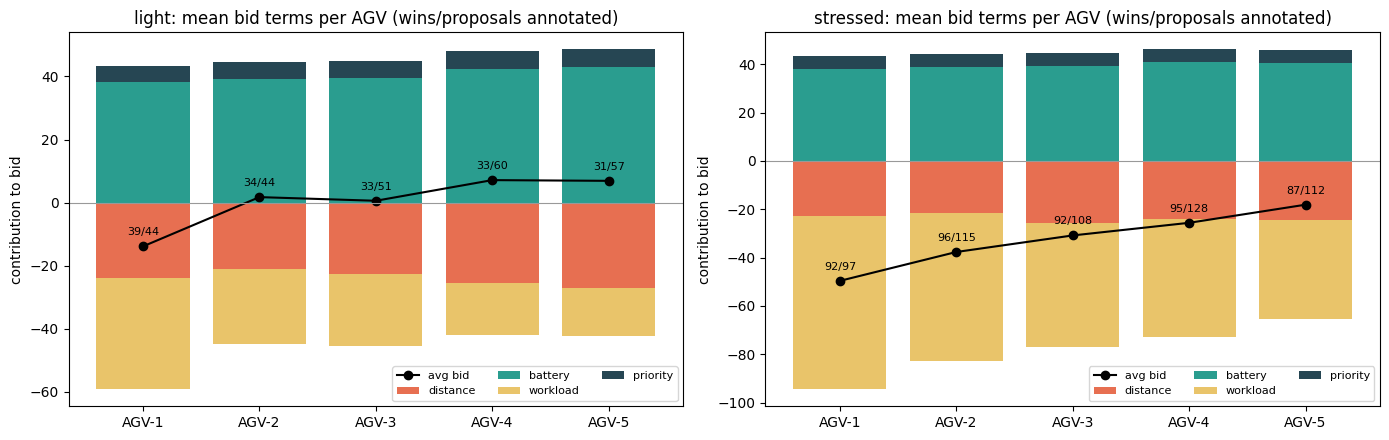

In [23]:
W_D, W_B, W_L, W_P = (MultiAGVSystem.W_D, MultiAGVSystem.W_B,
                      MultiAGVSystem.W_L, MultiAGVSystem.W_P)
TERMS = ["term_distance", "term_battery", "term_workload", "term_priority"]


def aggregate_negotiation(rows):
    labels = sorted({r["agv"] for r in rows})
    agg = {}
    for lb in labels:
        mine = [r for r in rows if r["agv"] == lb]
        n = len(mine)
        wins = sum(r["won"] for r in mine)
        avg = lambda k: sum(r[k] for r in mine) / n
        agg[lb] = {
            "proposals": n,
            "wins": wins,
            "win_rate": wins / n,
            "avg_bid": avg("bid"),
            "term_distance": -W_D * avg("dist"),
            "term_battery": W_B * avg("battery"),
            "term_workload": -W_L * avg("missions_completed"),
            "term_priority": W_P * avg("priority"),
            "avg_defect_bonus": avg("defect_bonus"),
        }
    return agg


for name, rows in NEGOTIATION_LOGS.items():
    agg = aggregate_negotiation(rows)
    print(f"=== {name} scenario -- {len(rows)} proposals over {len(EXPERIMENT_SEEDS)} coordinated runs ===\n")
    head = (f"{'AGV':<8}{'props':>7}{'wins':>6}{'win%':>7}{'avg bid':>10}"
            f"{'dist':>9}{'batt':>9}{'workload':>10}{'prio':>8}{'defect+':>9}")
    print(head)
    print("-" * len(head))
    for lb, a in agg.items():
        print(f"{lb:<8}{a['proposals']:>7}{a['wins']:>6}{a['win_rate'] * 100:>6.1f}%"
              f"{a['avg_bid']:>10.2f}{a['term_distance']:>9.2f}{a['term_battery']:>9.2f}"
              f"{a['term_workload']:>10.2f}{a['term_priority']:>8.2f}{a['avg_defect_bonus']:>9.2f}")
    print()

term_colors = {"term_distance": "#e76f51", "term_battery": "#2a9d8f",
               "term_workload": "#e9c46a", "term_priority": "#264653"}
fig, axes = plt.subplots(1, len(NEGOTIATION_LOGS),
                         figsize=(7 * len(NEGOTIATION_LOGS), 4.5), squeeze=False)
for ax, (name, rows) in zip(axes[0], NEGOTIATION_LOGS.items()):
    agg = aggregate_negotiation(rows)
    labels = list(agg)
    x = np.arange(len(labels))
    bot_pos = np.zeros(len(labels))
    bot_neg = np.zeros(len(labels))
    for term in TERMS:
        vals = np.array([agg[lb][term] for lb in labels])
        base = np.where(vals >= 0, bot_pos, bot_neg)
        ax.bar(x, vals, bottom=base, color=term_colors[term], label=term.replace("term_", ""))
        bot_pos = bot_pos + np.where(vals >= 0, vals, 0.0)
        bot_neg = bot_neg + np.where(vals < 0, vals, 0.0)
    avg_bid = [agg[lb]["avg_bid"] for lb in labels]
    ax.plot(x, avg_bid, "o-", color="black", label="avg bid")
    for xi in x:
        ax.annotate(f"{agg[labels[xi]]['wins']}/{agg[labels[xi]]['proposals']}",
                    (xi, avg_bid[xi]), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=8)
    ax.axhline(0, color="#999999", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f"{name}: mean bid terms per AGV (wins/proposals annotated)")
    ax.set_ylabel("contribution to bid")
    ax.legend(fontsize=8, ncol=3)
fig.tight_layout()
plt.show()


## Visualization

One coordinated run, animated -- AGVs colored by status with their battery % shown, pallets, the fixed and random obstacles, all three pedestrian crossings, and charging stations going down.

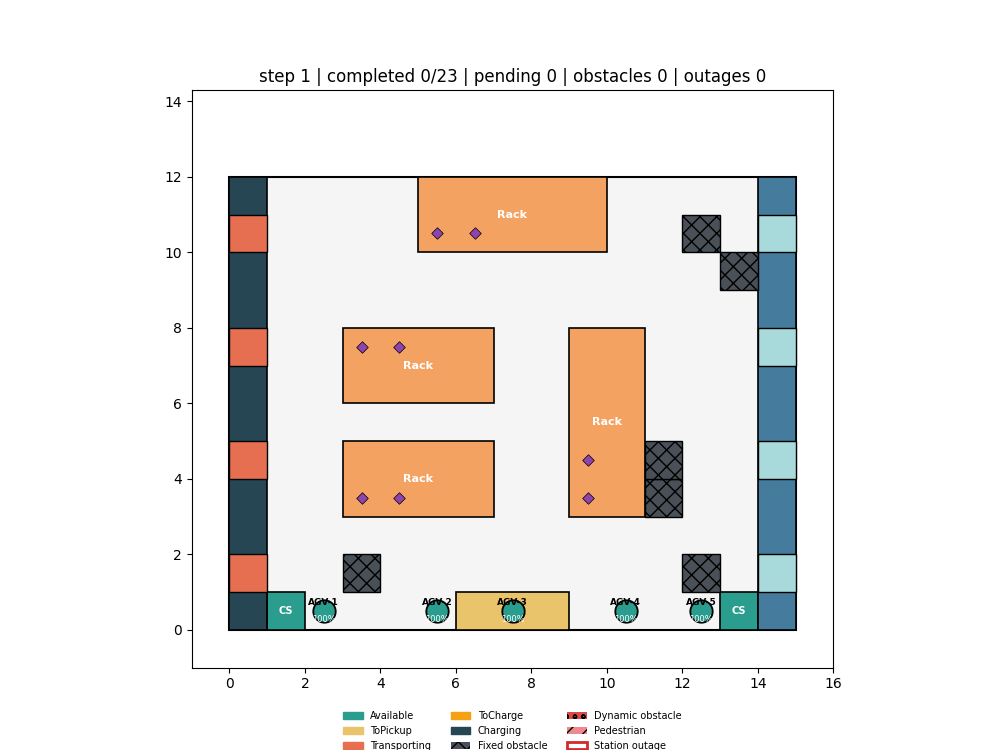

In [24]:
import matplotlib.animation as animation
from IPython.display import Image, display


def draw_environment_base(ax, config):
    # everything static -- boundary, grid, racks, CS, parking, dock -- redrawn each frame
    W, H = config["grid_width"], config["grid_height"]
    ax.add_patch(mpatches.Rectangle((0, 0), W, H, facecolor=COLORS["corridor"], edgecolor="black", linewidth=1.5))
    for gx in range(W + 1):
        ax.plot([gx, gx], [0, H], color="#dddddd", linewidth=0.5, zorder=0)
    for gy in range(H + 1):
        ax.plot([0, W], [gy, gy], color="#dddddd", linewidth=0.5, zorder=0)
    for r in config["racks"]:
        draw_block(ax, r["x"], r["y"], r["w"], r["h"], COLORS["rack"], "Rack", fontsize=8)
    for cs in config["charging_stations"]:
        draw_block(ax, cs["x"], cs["y"], cs["w"], cs["h"], COLORS["charging_station"], "CS", fontsize=7)
    p = config["parking_slot"]
    draw_block(ax, p["x"], p["y"], p["w"], p["h"], COLORS["parking_slot"], "Park", fontsize=6)
    pl = config["production_line"]
    draw_block(ax, pl["x"], pl["y"], pl["w"], pl["h"], COLORS["production_line"], "", fontsize=8)
    for oy in pl["output_rows"]:
        ax.add_patch(mpatches.Rectangle((pl["x"], oy), pl["w"], 1, facecolor="#e76f51", edgecolor="black", zorder=3))
    td = config["truck_dock"]
    draw_block(ax, td["x"], td["y"], td["w"], td["h"], COLORS["truck_dock"], "", fontsize=8)
    for dy in td["door_rows"]:
        ax.add_patch(mpatches.Rectangle((td["x"], dy), td["w"], 1, facecolor="#a8dadc", edgecolor="black", zorder=3))


anim_model = MultiAGVSystem(parameters={"seed": 303, "strategy": "coordinated"})
anim_model.run(steps=MultiAGVSystem.N_STEPS, display=False)

STATUS_COLORS_FLEET = {
    "Available": "#2a9d8f", "ToPickup": "#e9c46a", "Transporting": "#e76f51",
    "ToCharge": "#f4a213", "Charging": "#264653",
}

fig4, ax4 = plt.subplots(figsize=(10, 7.5))
n_missions_total = len(anim_model.missions)


def render_frame(i):
    ax4.clear()
    frame = anim_model.history[i]
    draw_environment_base(ax4, CONFIG)

    for (ox, oy) in anim_model.obstacles:
        ax4.add_patch(mpatches.Rectangle((ox, oy), 1, 1, facecolor="#495057", edgecolor="black",
                                          hatch="xx", zorder=2))
    for (dx, dy) in frame["dynamic_obstacles"]:
        ax4.add_patch(mpatches.Rectangle((dx, dy), 1, 1, facecolor="#d62828", edgecolor="black",
                                          hatch="oo", alpha=0.85, zorder=2))
    for (sx, sy) in frame["station_outage"]:
        ax4.add_patch(mpatches.Rectangle((sx, sy), 1, 1, facecolor="none", edgecolor="#d62828",
                                          linewidth=2.5, zorder=4))
        ax4.text(sx + 0.5, sy + 0.5, "X", ha="center", va="center", color="#d62828",
                 fontsize=13, weight="bold", zorder=5)
    for (px, py) in frame["pedestrian_cells"]:
        ax4.add_patch(mpatches.Rectangle((px, py), 1, 1, facecolor="#e63946", alpha=0.6,
                                          edgecolor="black", hatch="//", zorder=2))
    for pallet_id, pos, status in frame["pallets"]:
        if status != "being_transported":
            vx, vy = anim_model.visual_pallet_position(pos)
            ax4.scatter(vx + 0.5, vy + 0.5, marker="D", s=35,
                        color=COLORS["pallet_position"], edgecolor="black", linewidth=0.5, zorder=5)
    for label, pos, battery, status, carried in frame["agvs"]:
        color = STATUS_COLORS_FLEET.get(status, "gray")
        ax4.scatter(pos[0] + 0.5, pos[1] + 0.5, s=260, color=color, edgecolor="black", linewidth=1.3, zorder=6)
        ax4.text(pos[0] + 0.5, pos[1] + 0.72, label, ha="center", va="center",
                 fontsize=6.5, weight="bold", zorder=7)
        ax4.text(pos[0] + 0.5, pos[1] + 0.28, f"{battery:.0f}%", ha="center", va="center",
                 fontsize=6, color="white", zorder=7)

    ax4.set_xlim(-1, CONFIG["grid_width"] + 1)
    ax4.set_ylim(-1, CONFIG["grid_height"] + 2.3)
    ax4.set_aspect("equal")
    step_t, comp, pend = frame["t"], frame["completed"], frame["pending"]
    ax4.set_title(f"step {step_t} | completed {comp}/{n_missions_total} | pending {pend} | "
                  f"obstacles {len(frame['dynamic_obstacles'])} | outages {len(frame['station_outage'])}")
    legend_items = [mpatches.Patch(color=c, label=s) for s, c in STATUS_COLORS_FLEET.items()]
    legend_items.append(mpatches.Patch(facecolor="#495057", hatch="xx", label="Fixed obstacle"))
    legend_items.append(mpatches.Patch(facecolor="#d62828", hatch="oo", alpha=0.85, label="Dynamic obstacle"))
    legend_items.append(mpatches.Patch(facecolor="#e63946", alpha=0.6, hatch="//", label="Pedestrian"))
    legend_items.append(mpatches.Patch(facecolor="none", edgecolor="#d62828", linewidth=2, label="Station outage"))
    ax4.legend(handles=legend_items, loc="upper center", bbox_to_anchor=(0.5, -0.06),
               ncol=3, fontsize=7, frameon=False)


anim_m4 = animation.FuncAnimation(fig4, render_frame, frames=len(anim_model.history), interval=150)
anim_m4.save("agv_simulation_m4.gif", writer=animation.PillowWriter(fps=6))
plt.close(fig4)
display(Image(filename="agv_simulation_m4.gif"))


## Short analysis

**1. What specific problem did I identify in M3?**
Collision resolution was pretty dumb: whenever two AGVs wanted the same cell, the lower-index AGV always won, no matter what either one was actually doing or how long it had already been stuck. Same pair, same result, every single time.

**2. What intelligent technique did I pick?**
An MDP, solved by value iteration, for that hold/yield decision specifically. I kept A\* for routing and the auction/Cooperate-Defect negotiation from before (tweaked a bit, see above) as they were. I left battery/charging alone on purpose so the one technique I'm actually testing stays isolated to a single decision.

**3. Why this technique for this problem?**
Whether to hold or yield is basically a sequential decision under uncertainty -- what happens if I insist depends probabilistically on how long I've already been stuck -- and the state space is tiny (12 states), small enough to solve exactly instead of approximating it.

**4. What state/info does each AGV actually have?**
Its own position, battery, status and mission; the grid's walkable cells for routing; (aging, stake) for the collision decision; and for negotiation, its battery, how many missions it's already completed, and its distance to the mission it's bidding on.

**5. What decisions/actions can an AGV take?**
Cooperate or defect on a mission, bid a value, accept a mission it won, move a cell (or wait/sidestep), hold or yield in a standoff, and charge once its battery crosses the threshold.

**6. What reward/utility/probability model did I define?**
The full MDP (states, actions, transitions, reward, gamma) for the collision decision, plus the bidding utility carried over from M3 (distance/battery/workload, weighted) with a small bonus added for defectors.

**7. Where are the formulas?**
All in the code cells above, with the actual numbers plugged in rather than left symbolic -- the collision MDP's reward/transition functions and the Bellman equation it's solved with, the bidding formula, and the Cooperate/Defect payoff matrix. The report has the same formulas written out with the derivation.

**8. How do AGVs communicate?**
Through their bids, their Cooperate/Defect choice, and their MDP-based priority score during a standoff -- plus just seeing each other's position and path, since that's visible to every planner anyway.

**9. How do they negotiate or collaborate?**
A Cooperate/Defect round decides who's even in the running for a mission (defecting helps but isn't an automatic win), then the auction actually picks the winner. For a contested cell it's the MDP priority ranking that settles it directly -- nobody flips a coin, and the Mission Manager never picks who wins.

**10. How does coordinated differ from baseline?**
Baseline just gives the mission to whichever AGV is closest, no bidding, and collisions resolve by a fixed AGV order. Charging is exactly the same in both, on purpose, so it can't skew the comparison.

**11. How did I make sure the comparison was fair?**
Same seed for both runs of a pair, so same layout, same starting fleet, same dice going in. I also tested two very different load levels (light and stressed) instead of just one, so the comparison isn't tied to one arbitrary situation.

**12. What metrics did I use?**
Throughput, waiting/transit/total mission time, AGV utilization, fleet availability, distance traveled, time spent charging, collisions, and missions lost to a battery failure.

**13. Did it actually improve things? With numbers?**
Depends on the load, and I checked both directions instead of assuming one. Light load: not really -- collisions go up and most other things basically tie or get slightly worse, only waiting time comes out a bit better. Stressed load: yes on most fronts (more missions completed, better throughput and utilization, about 30% fewer collisions) except waiting time and battery failures, which get worse.

**14. When does it do well?**
Under more pressure: more missions in flight, faster battery drain, a longer shift. The MDP's advantages over a fixed rule (letting a long-stuck AGV eventually win, telling an idle AGV apart from one carrying cargo) only really pay off once standoffs happen often enough for that to matter.

**15. When does it do badly?**
Light traffic. Baseline's fixed rule is boring but perfectly stable, while the MDP's ranking can still shift as AGVs get more or less stuck, which occasionally reopens a standoff a fixed rule would've just settled once and left alone.

**16. What limitations are still there?**
The reward numbers in the MDP were picked by hand plus one round of fixing (the stake-tiering thing above), not properly tuned. I also don't fully know why coordinated loses more missions to battery under stress -- probably because it keeps AGVs working harder for longer, but I didn't check that against another design. The report's appendix has the full spread over the 8 seeds, not just the average, in case that matters for checking how solid any of this is.

**17. What would I improve with more time?**
Actually sweep the load parameters instead of testing two fixed points, to find where the crossover really sits. Dig into why battery failures go up for coordinated under stress. And there's a side finding I noticed almost by accident -- coordinated seems to spread work across the 5 AGVs a lot more evenly than baseline does -- that's in the report's appendix and could be worth chasing on its own.